<a href="https://colab.research.google.com/github/Alenushka2013/Bank-Marketing-Dataset-Machine-Learning-Project/blob/main/Mid_term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в барнку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

# **Exploratory Data Analysis**

## Аналіз числових ознак

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('whitegrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [36]:
df = pd.read_csv('https://raw.githubusercontent.com/Alenushka2013/Bank-Marketing-Dataset-Machine-Learning-Project/refs/heads/main/bank-additional-full.csv', sep = ';')

In [37]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [38]:
df.duplicated().sum()

np.int64(12)

In [39]:
df[df.duplicated(keep=False)].head(6)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no


In [40]:
# Видалення дублікатів та перевірка
df.drop_duplicates(keep='first',inplace=True)
df.duplicated().sum()

np.int64(0)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  floa

In [42]:
df.describe(percentiles = [0, 0.03, 0.25, 0.75, 0.98, 1]).round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00
mean,40.02,258.32,2.57,962.46,0.17,0.08,93.58,-40.50,3.62,5167.03
std,10.42,259.31,2.77,186.94,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
0%,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
3%,25.00,23.00,1.00,9.00,0.00,-3.00,92.43,-47.10,0.72,4991.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
98%,62.00,1052.50,11.00,999.00,2.00,1.40,94.46,-30.10,4.97,5228.10


**Спостереження**:
1. Змінна age має цілком правдоподібні значення, варто первірити на викиди, а також поцікавитися з якого віку банки оформлюють депозити.
2. Змінна duration(тривалість останнього контакту в секундах): найбільше значення 4918 секунд віповідає 1.4 годині, таке може бути. Ця змінна не буде використовуватися в фінальній моделі.
3. Змінна campaign(кількість контактів у межах поточної кампанії для цього клієнта): максимальне значення 56, завелике, потрібно перевірити на викиди.
4. Змінна pdays(кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії): значення 999 означає, що клієнт раніше не контактувався і таких значень більшість, потрібно буде перетворити дані, в такому вигляді не підходять для коректного аналізу.
5. Змінна previous(кількість контактів, здійснених до цієї кампанії для цього клієнта): значення від 0 до 7 цілком відповідають контексту.

Атрибути соціально-економічного контексту: emp.var.rate,	cons.price.idx,	cons.conf.idx,	euribor3m,	nr.employed мають невисокі значення стандартних відхилень, що говорить про невеликий розмах значень і швидше за все додаткові перетворення для цих змінних не знадобляться.

In [43]:
# Створення нової  числової колонки для категоріальної змінної
df['y_num'] = df['y'].map({'no': 0, 'yes': 1})

In [51]:
# Виділення числових та категоріальних колонок
numeric_cols = df.select_dtypes(include='number').columns
categor_cols = df.select_dtypes(include='object').columns[:-1]

In [52]:
categor_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

In [53]:
numeric_cols

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y_num'],
      dtype='object')

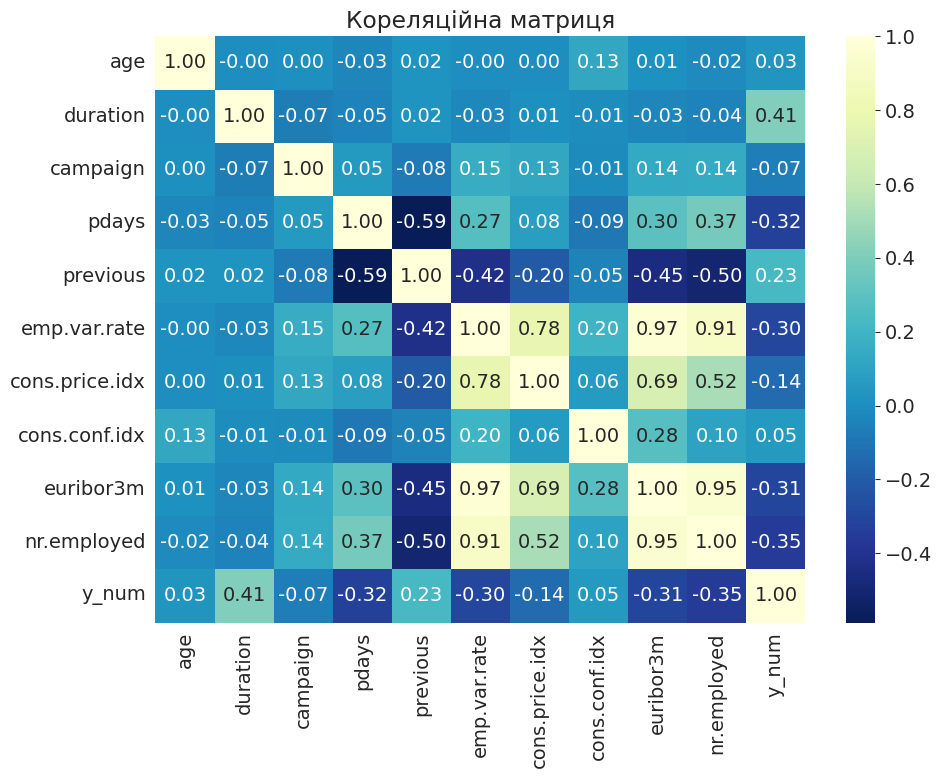

In [54]:
# Теплова карта кореляційної матриці
plt.figure(figsize=(10, 8)) # Розмір графіка: ширина=10, висота=8
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,             # показувати значення
    fmt=".2f",              # два знаки після коми
    cmap="YlGnBu_r")        # колірна гама: Yellow-Green-Blue
plt.title("Кореляційна матриця")
plt.tight_layout()
plt.show()

In [56]:
df[numeric_cols].corr().y_num.sort_values()[:-1]

,y_num
nr.employed,-0.354669
pdays,-0.324948
euribor3m,-0.307740
emp.var.rate,-0.298289
cons.price.idx,-0.136134
campaign,-0.066361
age,0.030381
cons.conf.idx,0.054802
previous,0.230202
duration,0.405297


## Розподіл цільової змінної

In [ ]:
df.y.value_counts(normalize = True).round(3)* 100

,proportion
y,
no,88.7
yes,11.3


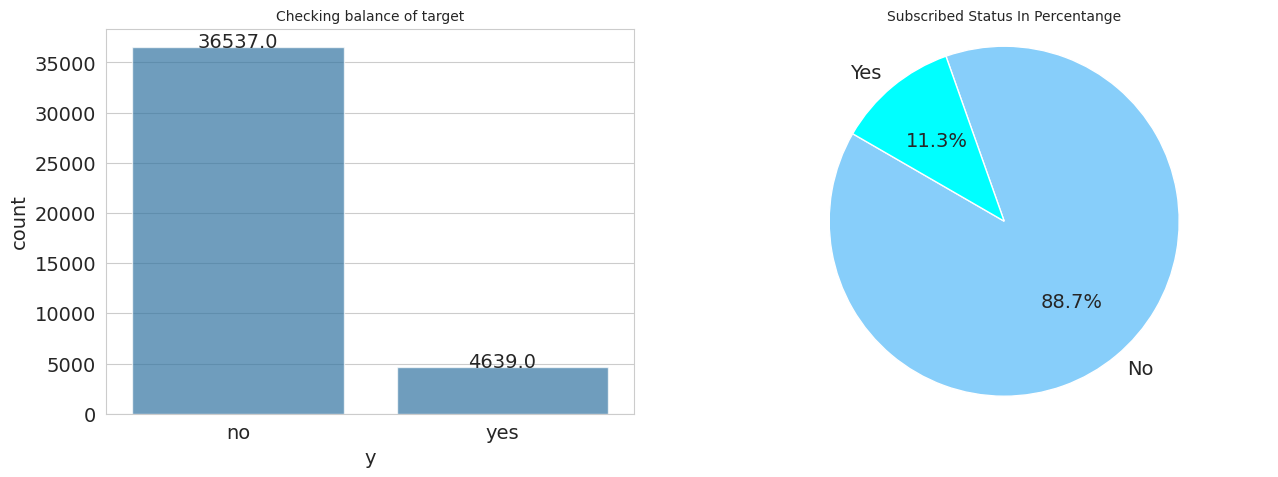

In [ ]:
plt.rcParams['figure.figsize']=15,5
plt.subplot(121)
plt.title('Checking balance of target', fontsize=10)
s = sns.countplot(x="y", data=df, alpha=0.7)
for p in s.patches:
    s.annotate(format(p.get_height(), '.1f'),
               (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 4),
                textcoords = 'offset points')


ax = plt.subplot(122)
mush_classpie = df['y'].value_counts()
mush_size = mush_classpie.values.tolist()
mush_types = mush_classpie.axes[0].tolist()
mush_labels = 'No', 'Yes'
colors = ['lightskyblue', '#00FFFF']
plt.title('Subscribed Status In Percentange', fontsize=10)
patches, texts, autotexts = plt.pie(mush_size, labels=mush_labels,  colors=colors,
        autopct='%1.1f%%',  startangle=150)
# for text,autotext in zip(texts,autotexts):
#     text.set_fontsize(14)
#     autotext.set_fontsize(14)

plt.axis('equal')
plt.show();

### Перетворення числової ознаки 'age'

In [ ]:
df[df.age > 60].y.value_counts().round(2)

,count
y,
no,495
yes,414


In [ ]:
df[df.age < 60].y.value_counts(normalize = True).round(2)

,proportion
y,
no,0.9
yes,0.1


In [ ]:
# бінування
bins = [0, 30, 34, 39, 46, 56, float('inf')]
labels = [0, 1, 2, 3, 4, 5]

df['age_cat'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

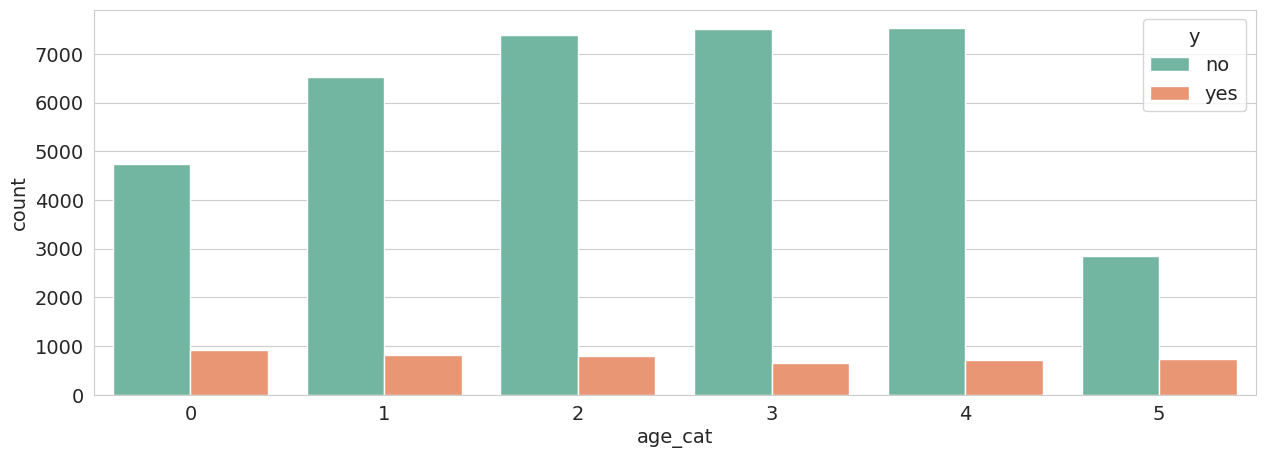

In [ ]:
sns.countplot(x='age_cat', hue='y', data=df, palette='Set2');

/tmp/ipython-input-900820140.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('age_group')['y_num'].count()


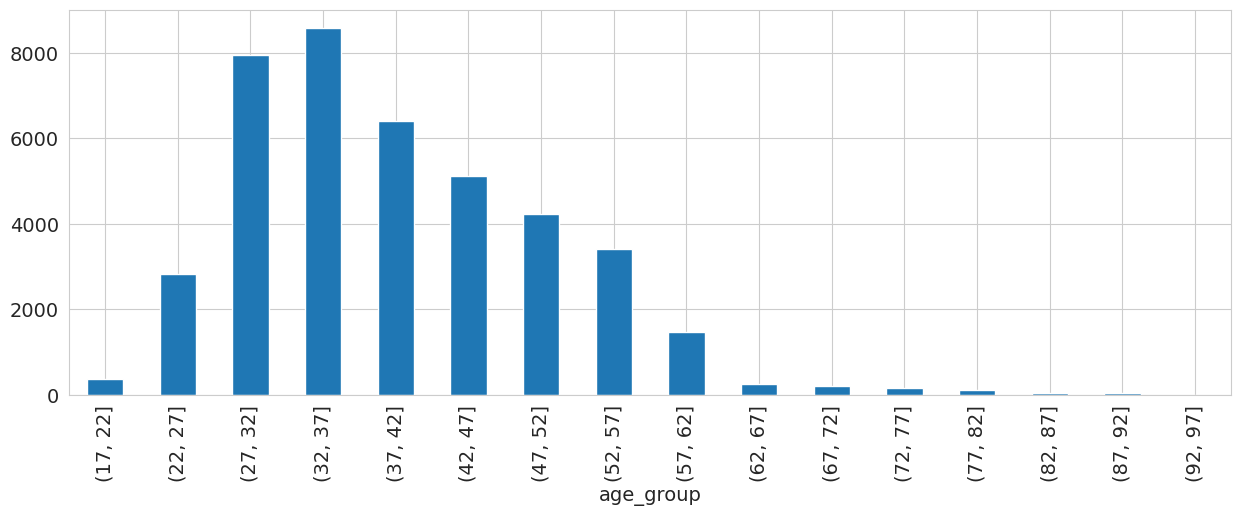

In [ ]:
df['age_group'] = pd.cut(df['age'], bins=range(17, 99, 5))  # по 10 років
grouped = df.groupby('age_group')['y_num'].count()
grouped.plot(kind='bar');

In [ ]:
# Автоматичне бінування з оптимізацією по цільовій
from sklearn.preprocessing import KBinsDiscretizer

est = KBinsDiscretizer(n_bins=6, encode='ordinal', strategy='quantile')
df['age_bin'] = est.fit_transform(df[['age']])

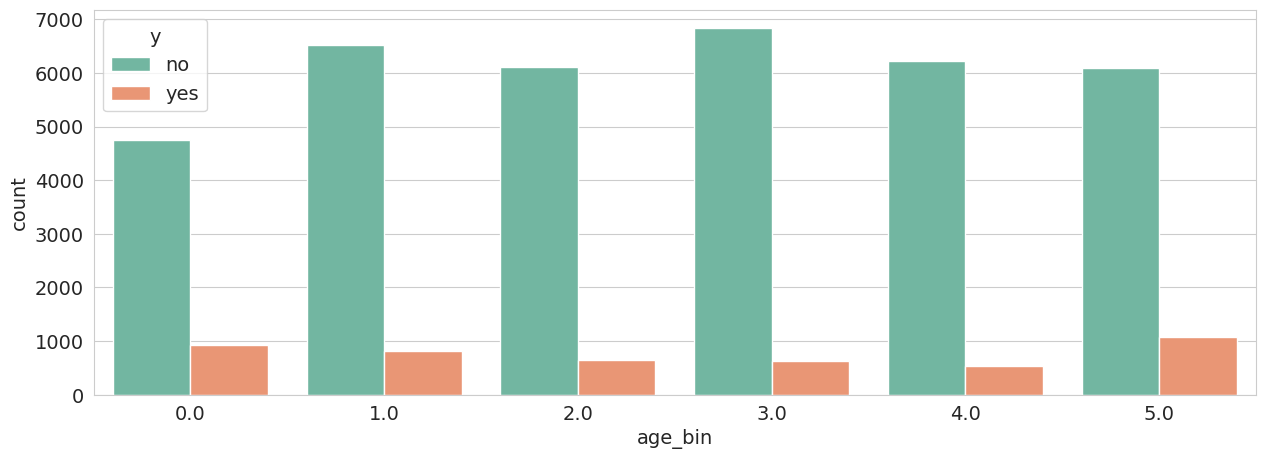

In [ ]:
sns.countplot(x='age_bin', hue='y', data=df, palette='Set2');

In [ ]:
df.groupby('age_cat').y_num.value_counts(normalize=True).round(3)*100

/tmp/ipython-input-1986984023.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_cat').y_num.value_counts(normalize=True).round(3)*100


age_cat  y_num
0        0        83.7
         1        16.3
1        0        88.9
         1        11.1
2        0        90.4
         1         9.6
3        0        92.0
         1         8.0
4        0        91.3
         1         8.7
5        0        79.3
         1        20.7
Name: proportion, dtype: float64

### Перетворення числової ознаки 'duration'

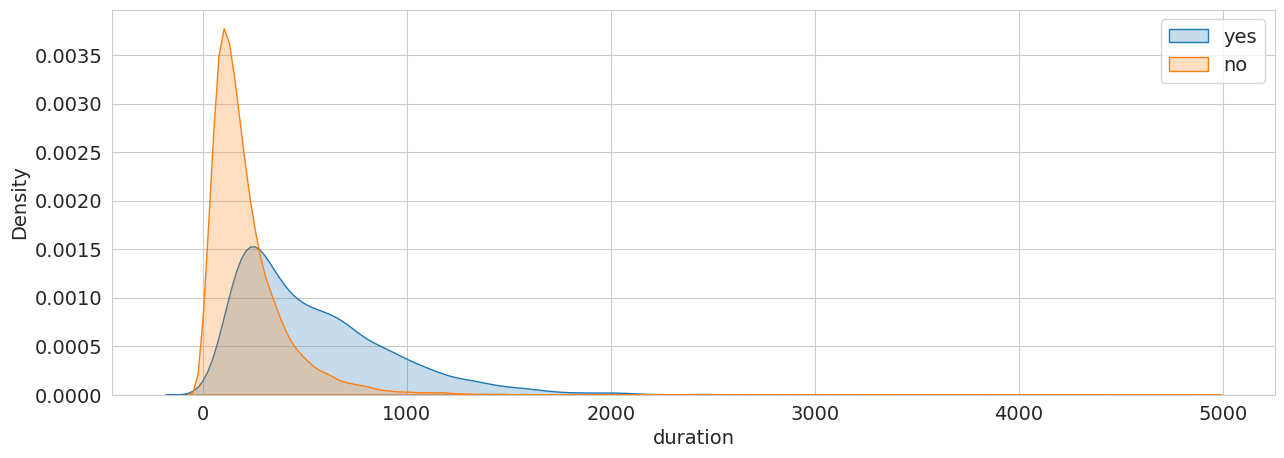

In [ ]:
sns.kdeplot(data=df[df['y'] == 'yes'], x='duration', label='yes', fill=True)
sns.kdeplot(data=df[df['y'] == 'no'], x='duration', label='no', fill=True)
plt.legend()
plt.show()

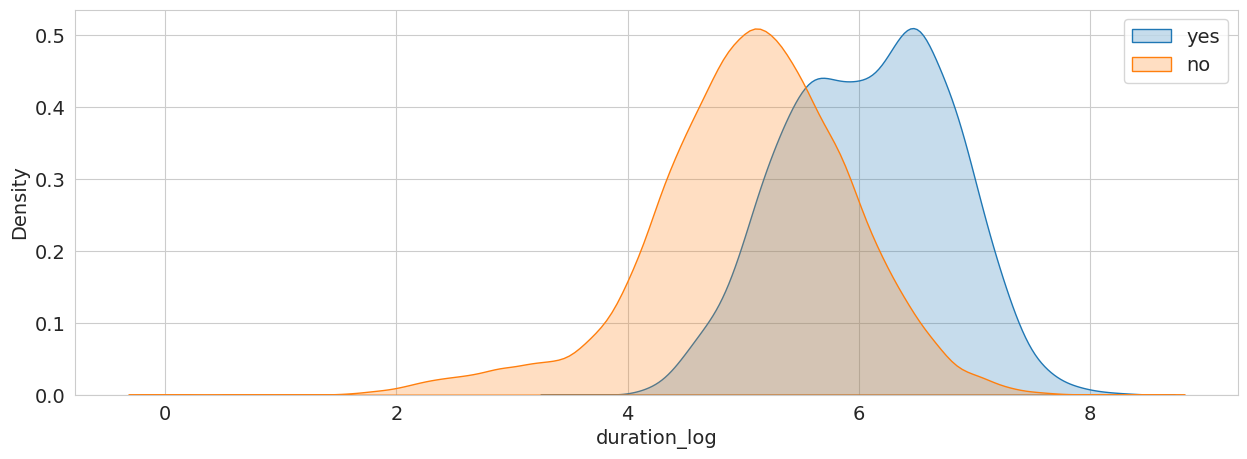

In [ ]:
df['duration_log'] = np.log1p(df['duration'])
sns.kdeplot(data=df[df['y'] == 'yes'], x='duration_log', label='yes', fill=True)
sns.kdeplot(data=df[df['y'] == 'no'], x='duration_log', label='no', fill=True)
plt.legend()
plt.show()

### Перетворення числової ознаки 'campaign'

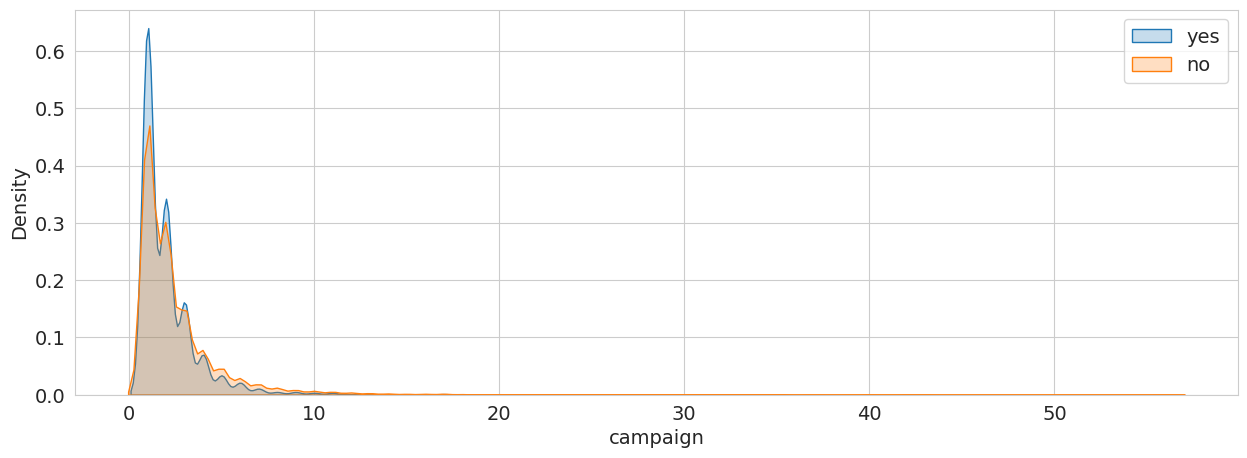

In [ ]:
sns.kdeplot(data=df[df['y'] == 'yes'], x='campaign', label='yes', fill=True)
sns.kdeplot(data=df[df['y'] == 'no'], x='campaign', label='no', fill=True)
plt.legend()
plt.show()

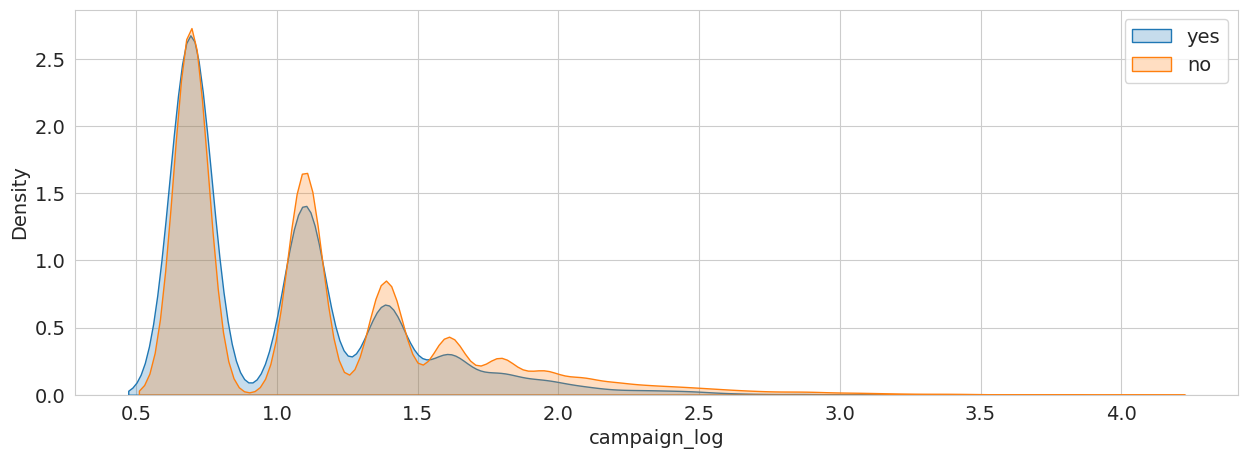

In [ ]:
df['campaign_log'] = np.log1p(df['campaign'])
sns.kdeplot(data=df[df['y'] == 'yes'], x='campaign_log', label='yes', fill=True)
sns.kdeplot(data=df[df['y'] == 'no'], x='campaign_log', label='no', fill=True)
plt.legend()
plt.show()

### Перетворення числової ознаки 'pdays'

In [ ]:
df.pdays.value_counts().sort_index().to_frame().T

pdays,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,25,26,27,999
count,15,26,61,439,118,46,412,60,18,64,...,8,7,3,1,2,3,1,1,1,39661


In [ ]:
# Створити нову бінарну ознаку: був контакт чи ні
df['had_contact_before'] = (df['pdays'] != 999).astype(int) # 1 — клієнт мав попередній контакт, 0 — не мав

# залишити NaN, якщо модель може з ними працювати (наприклад, XGBoost, LightGBM).
df['pdays_clean'] = df['pdays'].replace(999, np.nan)

df['pdays_change'] = df['pdays'].replace(999, 0)

### Аналіз числових ознак 'previous', 'emp.var.rate',	'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'

In [ ]:
df.previous.value_counts().sort_index().to_frame().T

previous,0,1,2,3,4,5,6,7
count,35551,4561,754,216,70,18,5,1


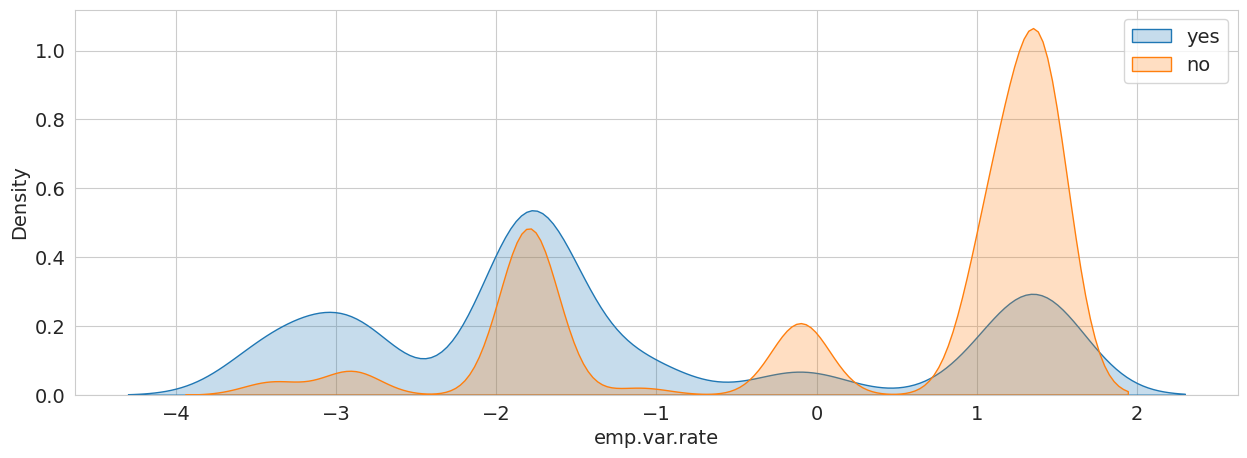

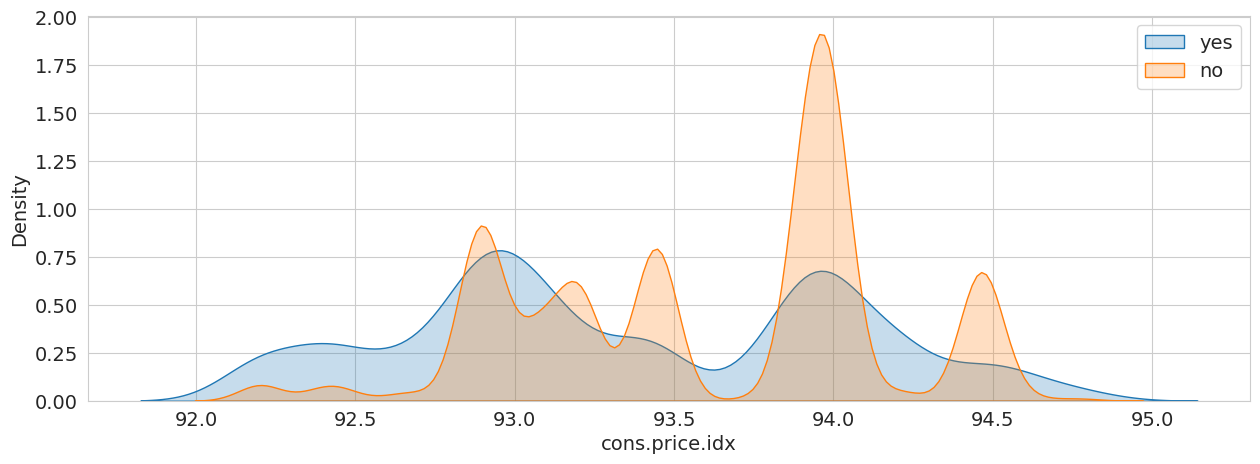

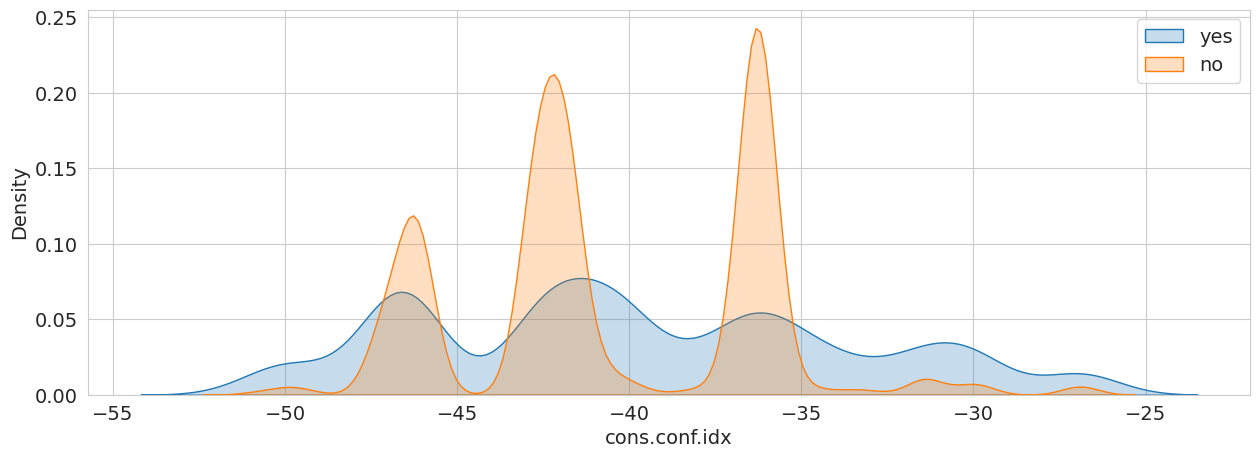

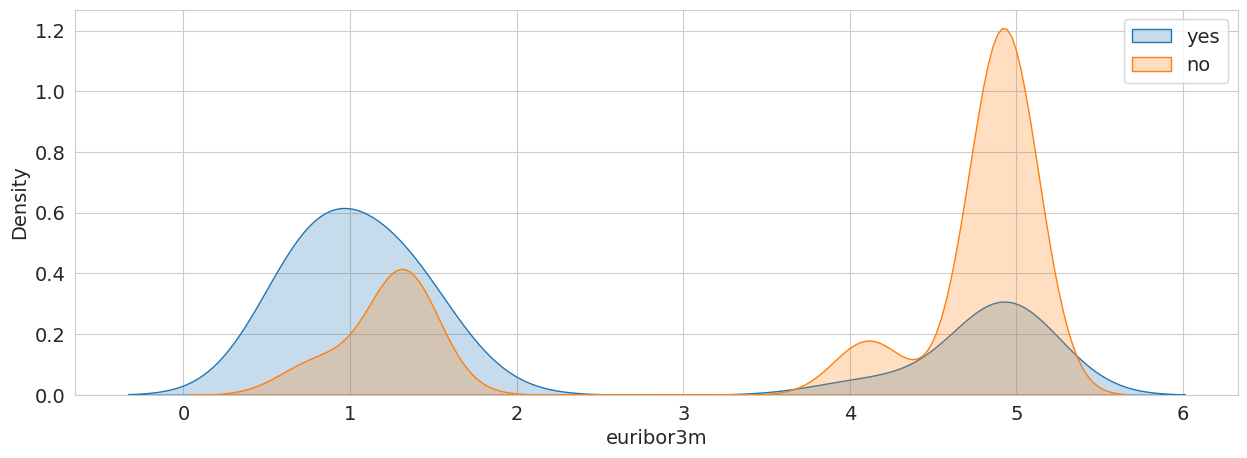

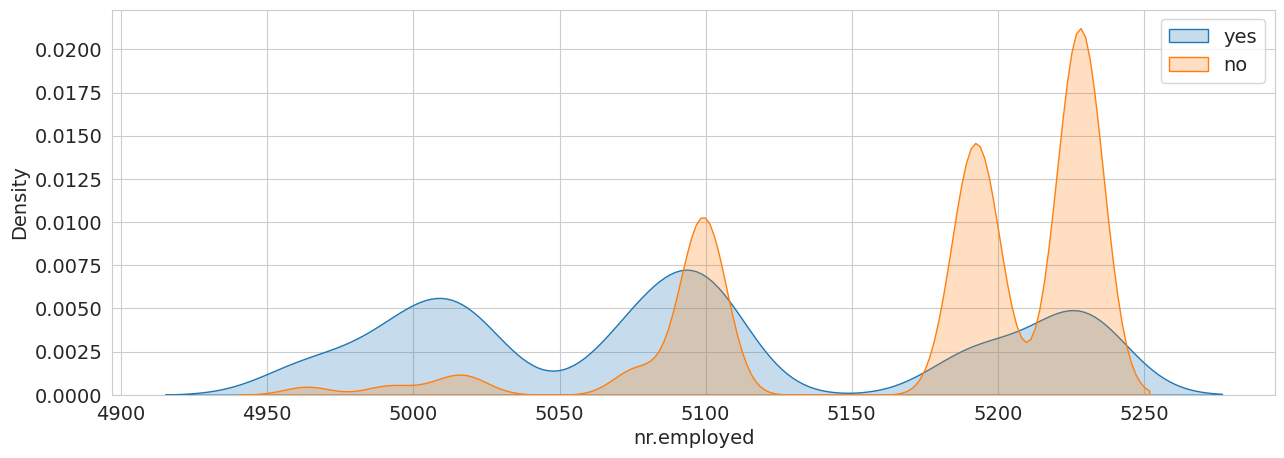

In [ ]:
for col in ['emp.var.rate',	'cons.price.idx','cons.conf.idx', 'euribor3m', 'nr.employed']:
  # sns.countplot(x=col, hue='y', data=df, palette='Set2')
  # plt.show()

  sns.kdeplot(data=df[df['y'] == 'yes'], x=col, label='yes', fill=True)
  sns.kdeplot(data=df[df['y'] == 'no'], x=col, label='no', fill=True)
  plt.legend()
  plt.show()

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,y,y_num,age_cat,age_group,age_bin,duration_log,campaign_log,had_contact_before,pdays_clean,pdays_change
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,no,0,5,"(52, 57]",5.0,5.568345,0.693147,0,NaN,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,no,0,5,"(52, 57]",5.0,5.010635,0.693147,0,NaN,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,no,0,2,"(32, 37]",2.0,5.424950,0.693147,0,NaN,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,no,0,3,"(37, 42]",3.0,5.023881,0.693147,0,NaN,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,no,0,5,"(52, 57]",5.0,5.730100,0.693147,0,NaN,0


In [ ]:
numeric_cols

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y_num'],
      dtype='object')

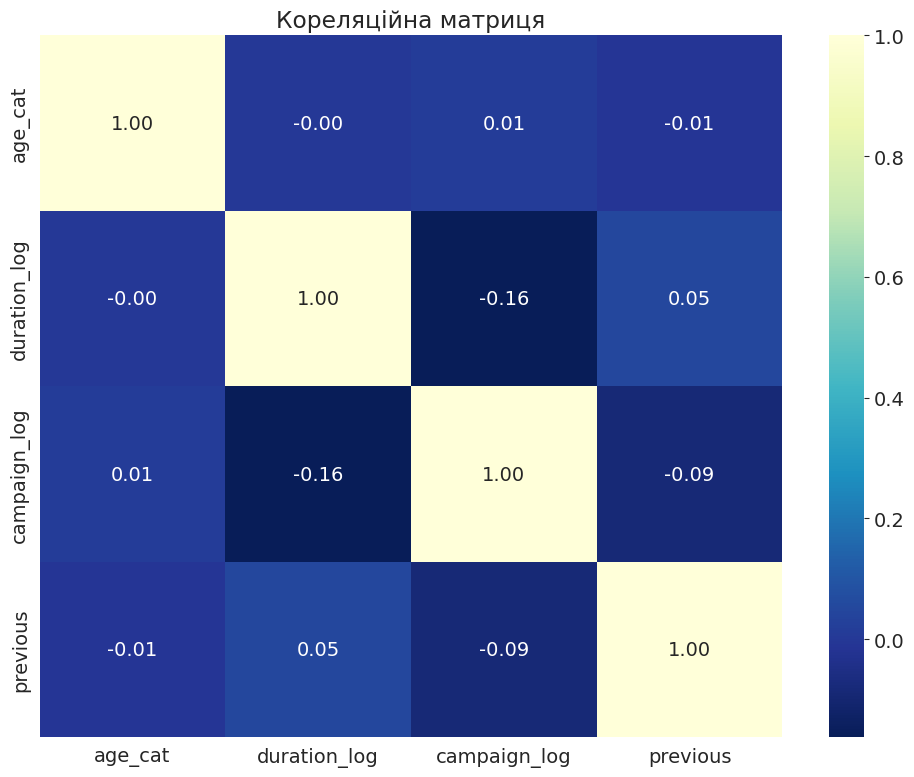

In [ ]:
col_for_corr = ['age_cat',  'duration_log', 'campaign_log', 'previous']# , 'emp.var.rate','cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y_num']
# Теплова карта кореляційної матриці з налаштуваннями
plt.figure(figsize=(10, 8))  # Розмір графіка: ширина=12, висота=10
sns.heatmap(
    df[col_for_corr].corr(),
    annot=True,             # показувати значення
    fmt=".2f",              # два знаки після коми
    cmap="YlGnBu_r")          # колірна гама: Yellow-Green-Blue
plt.title("Кореляційна матриця")
plt.tight_layout()
plt.show()

## Аналіз та перетворення категоріальних ознак

In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

frames = []

for column in categorical_columns:
    unique_values = df[column].unique()
    # Create a DataFrame for each column's unique values
    temp_df = pd.DataFrame({'Column Name': column, 'Unique Values': [unique_values], 'Count Unique Values': len(unique_values)})
    frames.append(temp_df)

# Concatenate all DataFrames in the list
unique_values_df = pd.concat(frames, ignore_index=True)
pd.set_option('display.max_colwidth', None)

display(unique_values_df)

,Column Name,Unique Values,Count Unique Values
0,job,"[housemaid, services, admin., blue-collar, technician, retired, management, unemployed, self-employed, unknown, entrepreneur, student]",12
1,marital,"[married, single, divorced, unknown]",4
2,education,"[basic.4y, high.school, basic.6y, basic.9y, professional.course, unknown, university.degree, illiterate]",8
3,default,"[no, unknown, yes]",3
4,housing,"[no, yes, unknown]",3
5,loan,"[no, yes, unknown]",3
6,contact,"[telephone, cellular]",2
7,month,"[may, jun, jul, aug, oct, nov, dec, mar, apr, sep]",10
8,day_of_week,"[mon, tue, wed, thu, fri]",5
9,poutcome,"[nonexistent, failure, success]",3


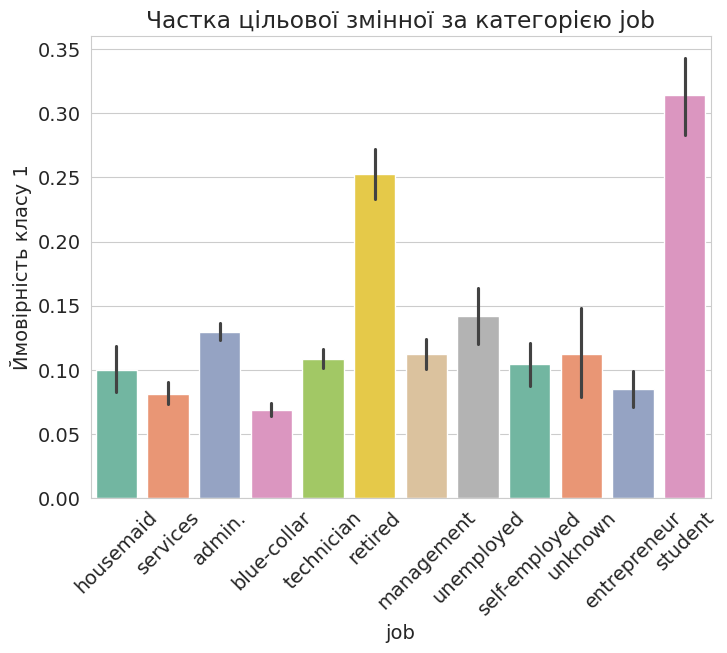

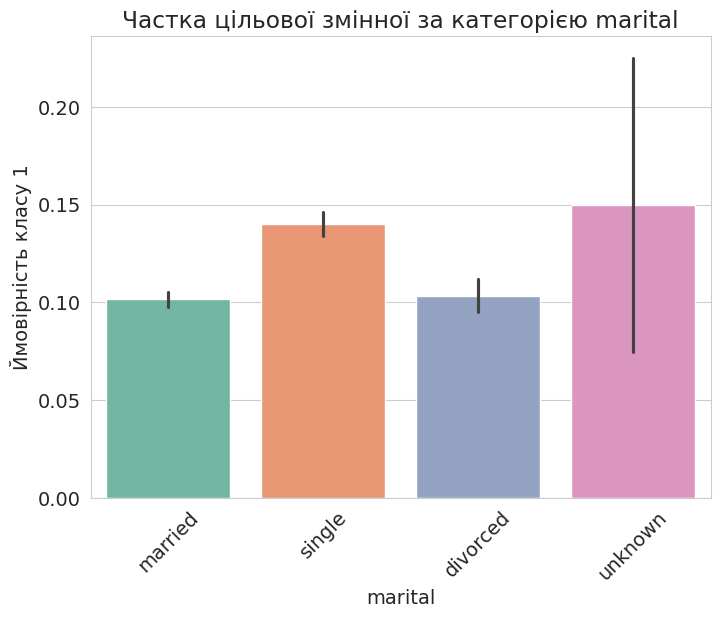

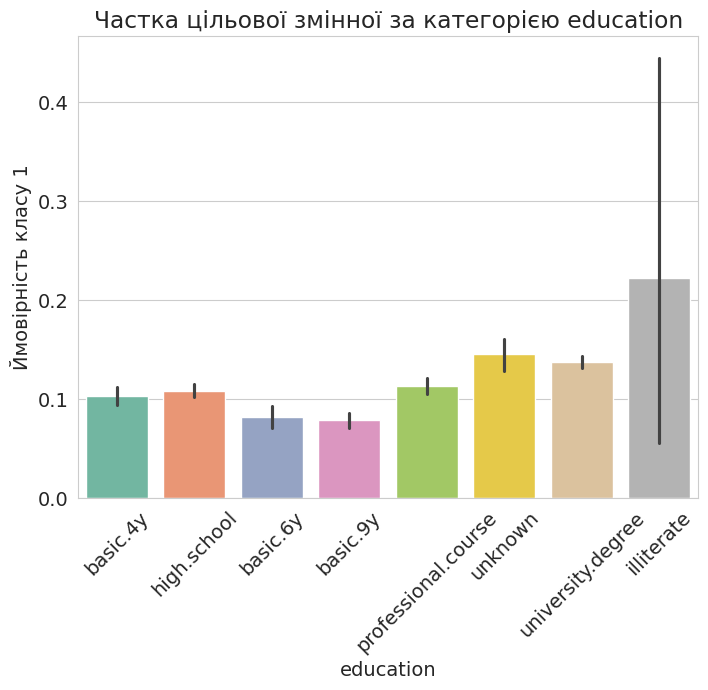

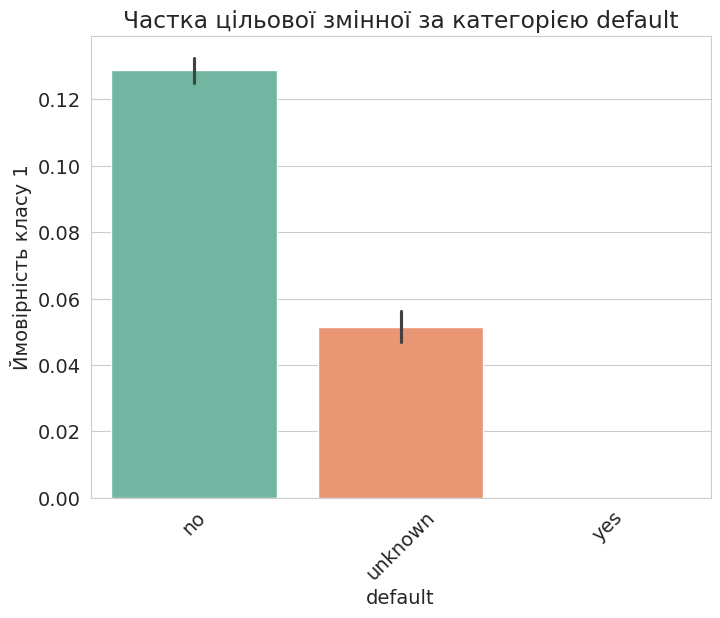

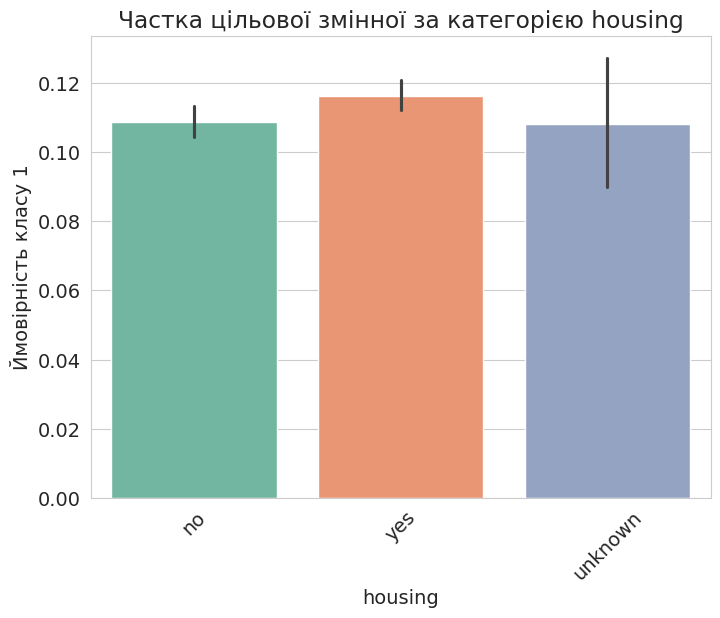

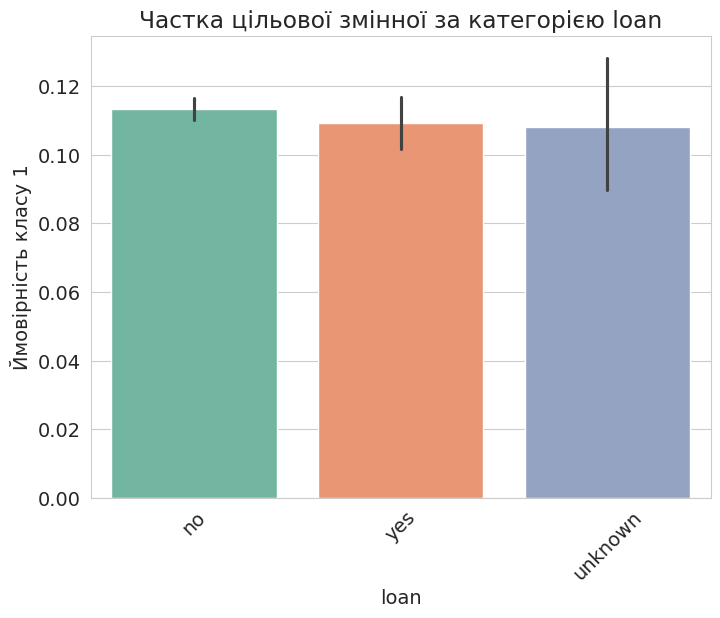

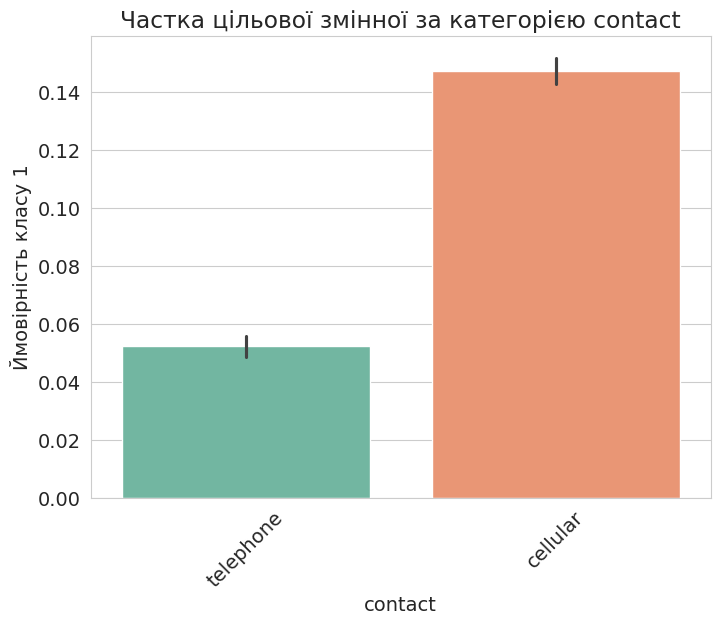

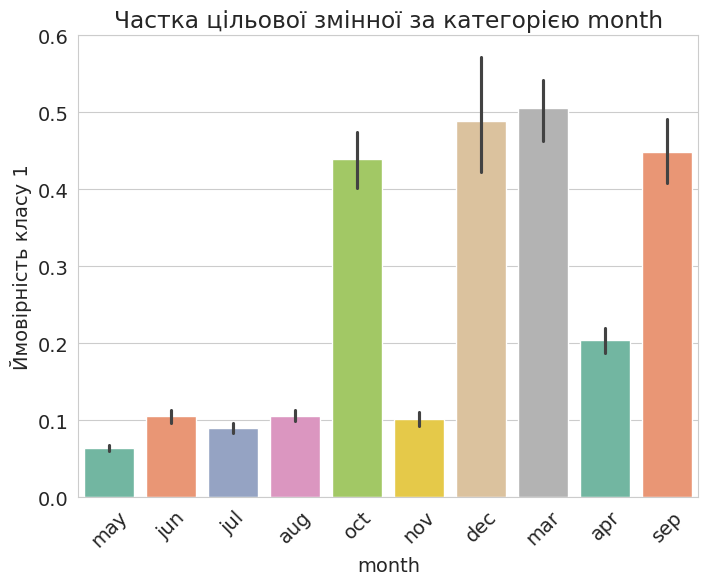

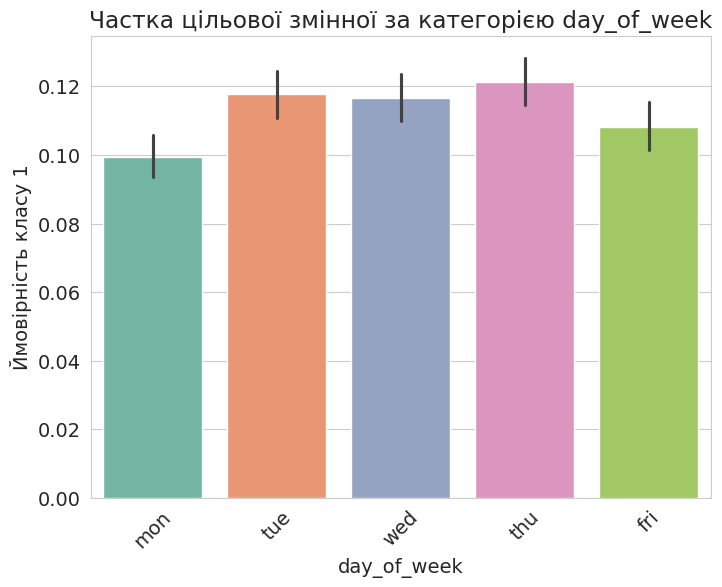

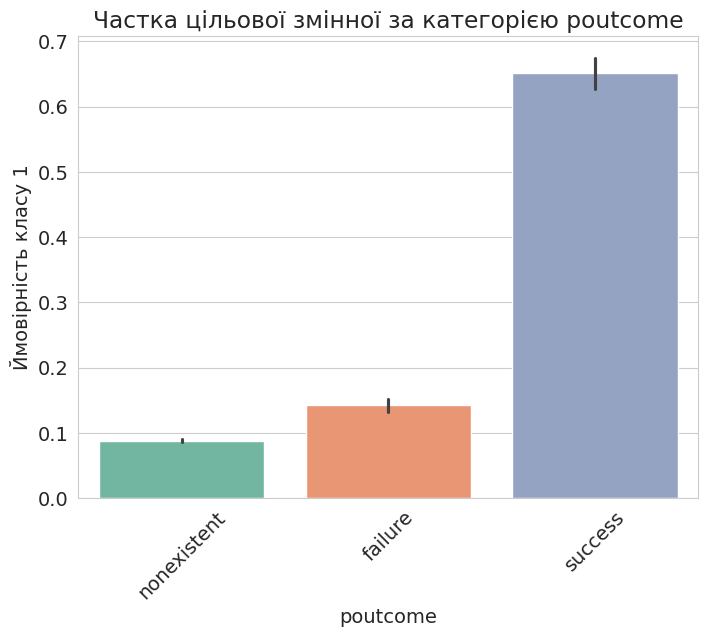

In [ ]:
for col in categor_cols:
  plt.figure(figsize=(8, 6))
  sns.barplot(
      x=col,
      y='y_num',
      data=df,
      estimator=np.mean,
      hue=col,     # додаємо hue, щоб palette спрацював
      dodge=False,                   # щоб уникнути розділення барів
      palette='Set2',
      legend=False,                   # відключити зайву легенду

  )
  plt.ylabel('Ймовірність класу 1')
  plt.xticks(rotation=45)
  plt.title(f'Частка цільової змінної за категорією {col}')
  plt.show()

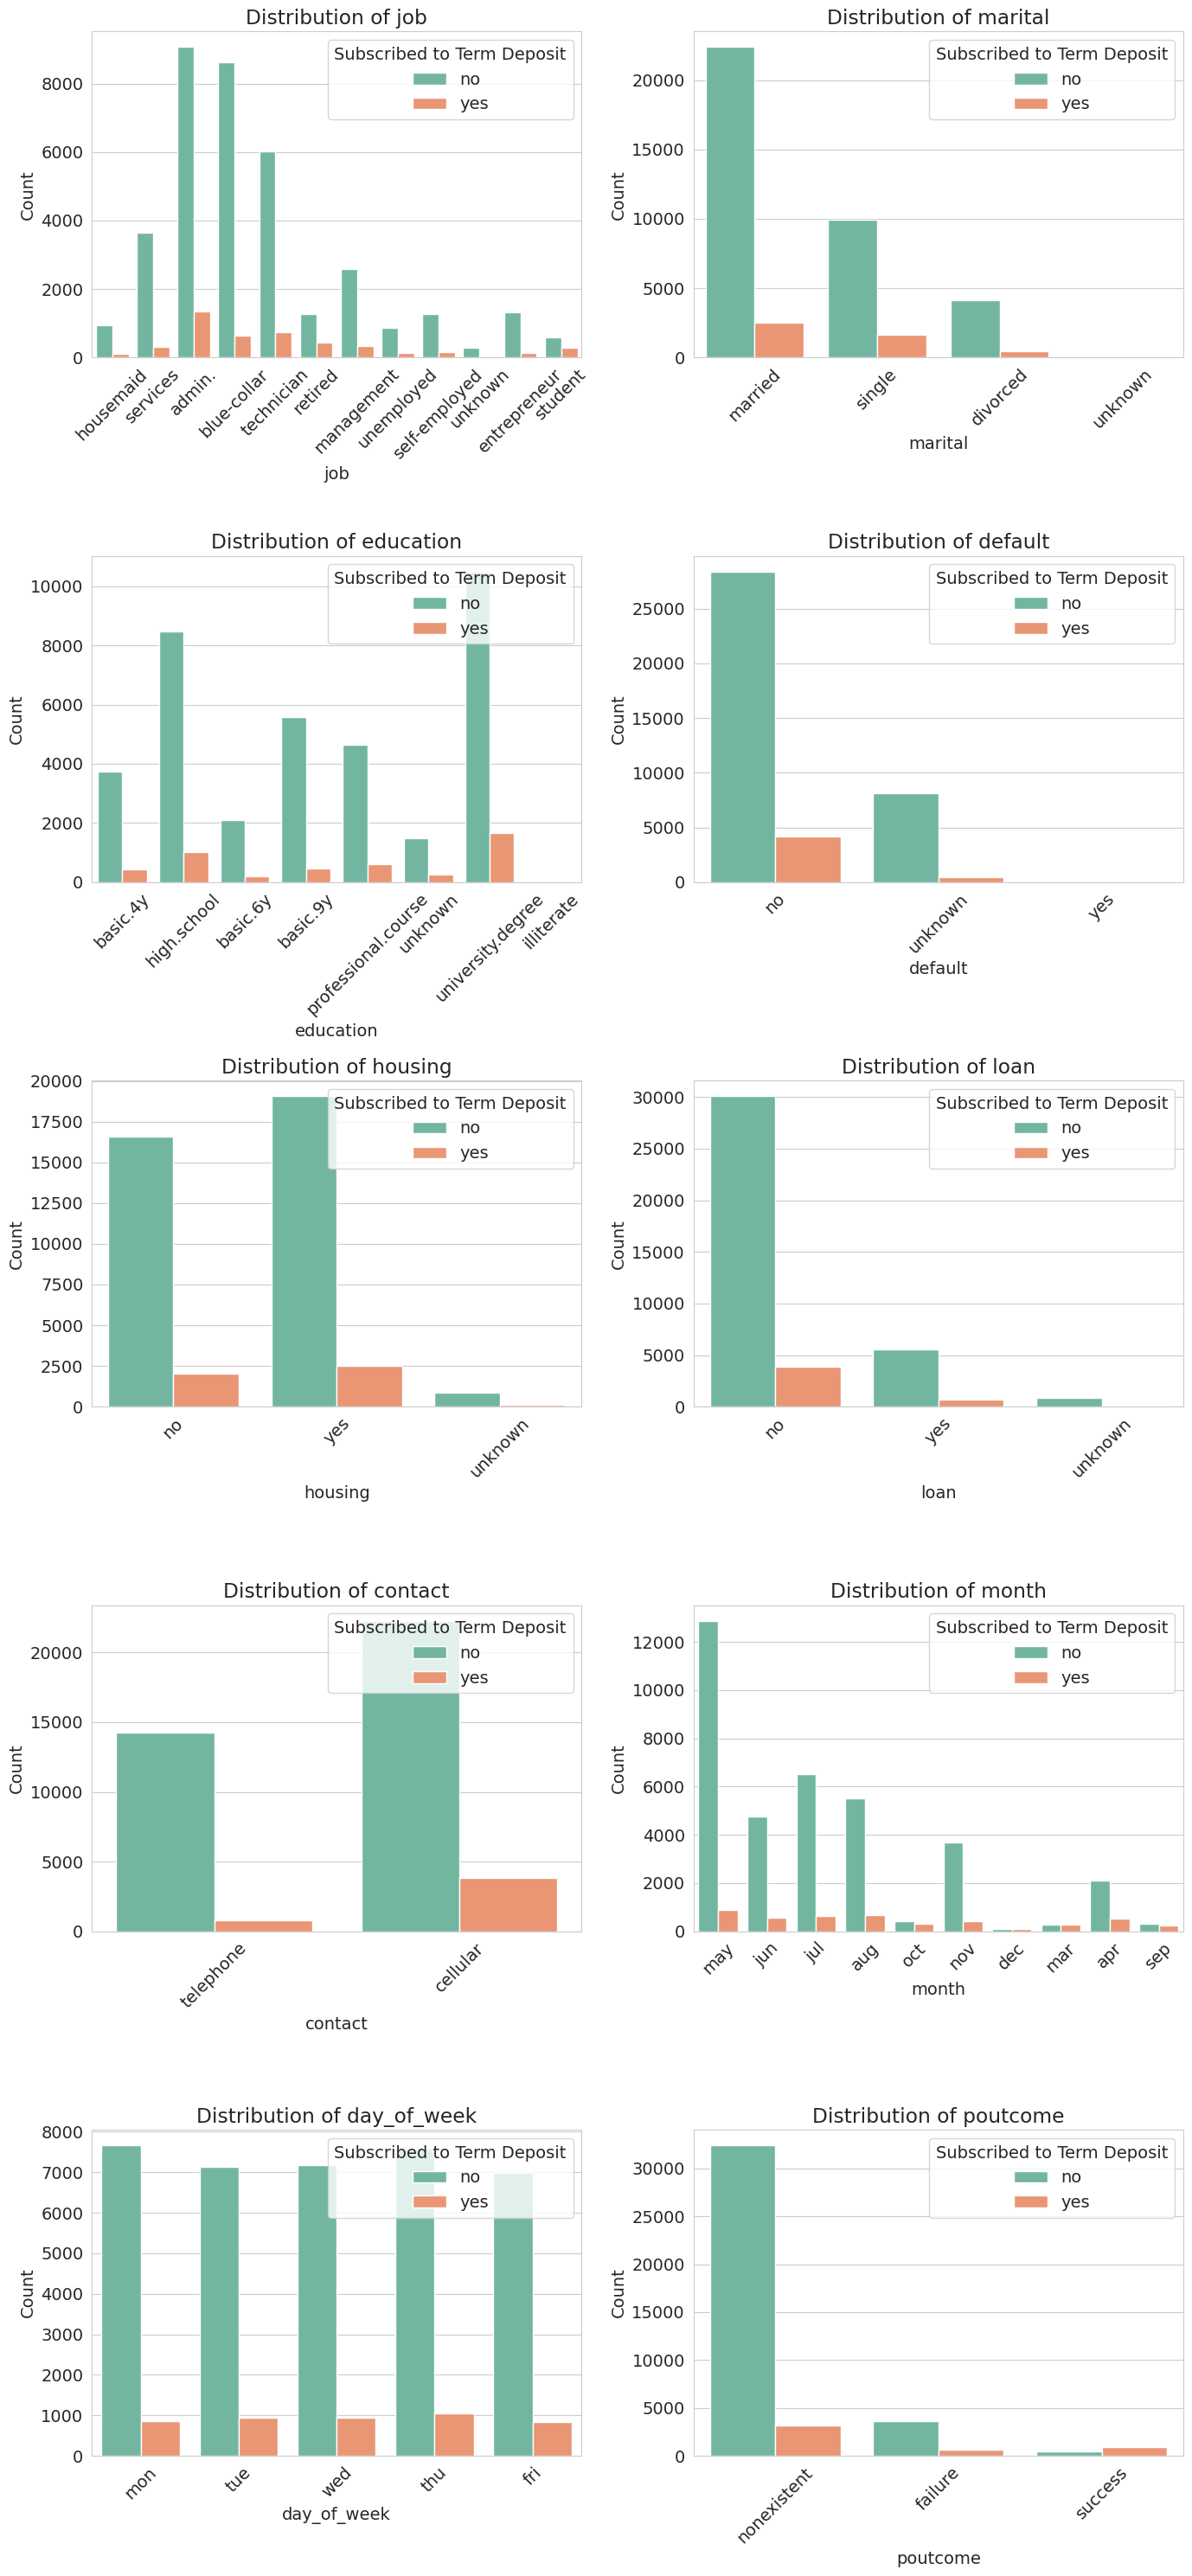

In [ ]:
# Create a list of columns except 'y' and 'age'
columns_to_plot = categor_cols #df.drop(['y', 'age', 'y_num'], axis=1).columns.tolist()

# Define the number of columns and rows for subplots
num_cols = 2 # Number of columns for subplots
num_rows = -(-len(columns_to_plot) // num_cols)  # Calculate the number of rows

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 30))

# Flatten axes if there's only one row
if num_rows == 1:
    axes = [axes]

# Iterate through columns and create count plots
for i, col in enumerate(columns_to_plot):
    sns.countplot(x=col, hue='y', data=df, ax=axes[i // num_cols, i % num_cols],palette='Set2')
    axes[i // num_cols, i % num_cols].set_title(f'Distribution of {col}') # for Subscribed and Non-Subscribed')
    axes[i // num_cols, i % num_cols].set_xlabel(col)
    axes[i // num_cols, i % num_cols].set_ylabel('Count')
    axes[i // num_cols, i % num_cols].legend(title='Subscribed to Term Deposit', loc='upper right')
    axes[i // num_cols, i % num_cols].tick_params(axis='x', rotation=45)  # Rotate x-axis labels

# Adjust layout to avoid overlapping
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   age                 41176 non-null  int64   
 1   job                 41176 non-null  object  
 2   marital             41176 non-null  object  
 3   education           41176 non-null  object  
 4   default             41176 non-null  object  
 5   housing             41176 non-null  object  
 6   loan                41176 non-null  object  
 7   contact             41176 non-null  object  
 8   month               41176 non-null  object  
 9   day_of_week         41176 non-null  object  
 10  duration            41176 non-null  int64   
 11  campaign            41176 non-null  int64   
 12  pdays               41176 non-null  int64   
 13  previous            41176 non-null  int64   
 14  poutcome            41176 non-null  object  
 15  emp.var.rate        41176 non-null  float

In [ ]:
df[df.marital == 'unknown'].y.value_counts(normalize = True)

,proportion
y,
no,0.85
yes,0.15


In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'y_num', 'age_cat',
       'age_group', 'age_bin', 'duration_log', 'campaign_log',
       'had_contact_before', 'pdays_clean', 'pdays_change'],
      dtype='object')

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,y,y_num,age_cat,age_group,age_bin,duration_log,campaign_log,had_contact_before,pdays_clean,pdays_change
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,no,0,5,"(52, 57]",5.0,5.568345,0.693147,0,NaN,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,no,0,5,"(52, 57]",5.0,5.010635,0.693147,0,NaN,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,no,0,2,"(32, 37]",2.0,5.424950,0.693147,0,NaN,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,no,0,3,"(37, 42]",3.0,5.023881,0.693147,0,NaN,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,no,0,5,"(52, 57]",5.0,5.730100,0.693147,0,NaN,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   age                 41176 non-null  int64   
 1   job                 41176 non-null  object  
 2   marital             41176 non-null  object  
 3   education           41176 non-null  object  
 4   default             41176 non-null  object  
 5   housing             41176 non-null  object  
 6   loan                41176 non-null  object  
 7   contact             41176 non-null  object  
 8   month               41176 non-null  object  
 9   day_of_week         41176 non-null  object  
 10  duration            41176 non-null  int64   
 11  campaign            41176 non-null  int64   
 12  pdays               41176 non-null  int64   
 13  previous            41176 non-null  int64   
 14  poutcome            41176 non-null  object  
 15  emp.var.rate        41176 non-null  float

# Тренування моделей

## Preprocessing

In [ ]:
df_log_reg = df[['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'duration', 'day_of_week', 'campaign', 'pdays_change',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'had_contact_before', 'y_num']].copy()

In [ ]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df_log_reg, stratify = df['y_num'], test_size=0.2, random_state=42)
print('train_df.shape :', train_df.shape)
print('val_df.shape :', val_df.shape)

train_df.shape : (32940, 22)
val_df.shape : (8236, 22)


In [ ]:
input_cols = list(train_df.columns)[:-1]
target_col = 'y_num'
print(input_cols)

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'duration', 'day_of_week', 'campaign', 'pdays_change', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'had_contact_before']


In [ ]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [ ]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [ ]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_inputs[numeric_cols])

train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

train_inputs[numeric_cols].describe().round(2)

,age,duration,campaign,pdays_change,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,had_contact_before
count,32940.00,32940.00,32940.00,32940.00,32940.00,32940.00,32940.00,32940.00,32940.00,32940.00,32940.00
mean,0.28,0.06,0.03,0.01,0.02,0.73,0.54,0.43,0.68,0.77,0.04
std,0.13,0.06,0.05,0.05,0.07,0.33,0.23,0.19,0.39,0.27,0.19
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.19,0.02,0.00,0.00,0.00,0.33,0.34,0.34,0.16,0.51,0.00
50%,0.26,0.04,0.02,0.00,0.00,0.94,0.60,0.38,0.96,0.86,0.00
75%,0.37,0.08,0.04,0.00,0.00,1.00,0.70,0.60,0.98,1.00,0.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop =  'first', sparse_output=False, handle_unknown='infrequent_if_exist')
encoder.fit(train_inputs[categorical_cols])

encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

In [ ]:
display(train_inputs.head()), display(val_inputs.head())

,age,job,marital,education,default,housing,loan,contact,month,duration,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
36454,0.086420,technician,single,professional.course,no,no,no,cellular,jun,0.029055,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1233,0.185185,blue-collar,married,professional.course,no,no,no,telephone,may,0.266492,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
24111,0.197531,self-employed,single,university.degree,no,no,no,telephone,nov,0.040010,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
15516,0.259259,entrepreneur,married,basic.9y,no,no,yes,telephone,jul,0.030722,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
17916,0.271605,services,married,high.school,no,yes,yes,cellular,jul,0.046916,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


,age,job,marital,education,default,housing,loan,contact,month,duration,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
8490,0.222222,services,married,high.school,unknown,no,no,telephone,jun,0.041200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
40844,0.160494,student,single,professional.course,no,yes,no,cellular,sep,0.067159,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
35681,0.246914,self-employed,single,basic.4y,no,yes,no,cellular,may,0.042867,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
35994,0.172840,blue-collar,single,professional.course,no,no,no,cellular,may,0.074780,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
21961,0.172840,technician,married,university.degree,no,unknown,unknown,cellular,aug,0.020957,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


(None, None)

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear')

In [ ]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

model.fit(X_train, train_targets)

train_preds = model.predict(X_train)  # передбачення моделі на тренувальних даних
val_preds = model.predict(X_val)      # передбачення моделі на валідаційних даних

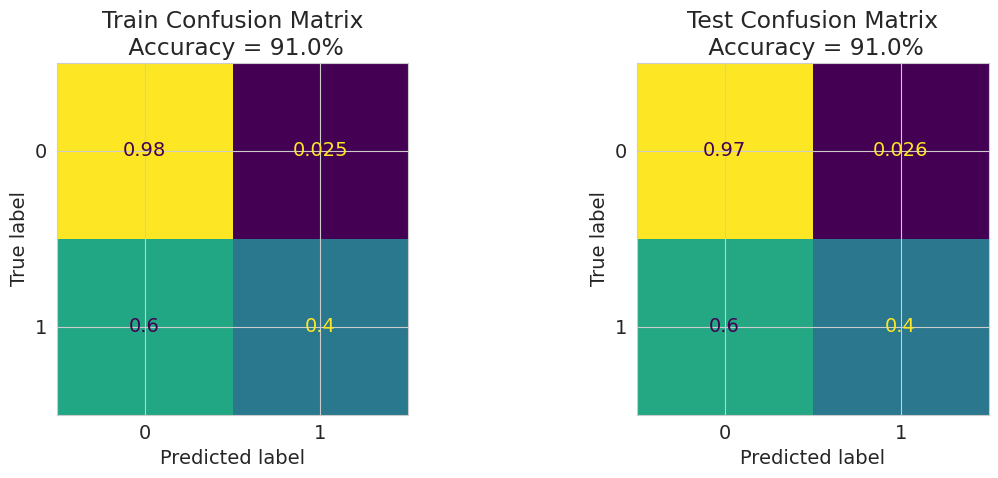

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score

# Обчислюємо матриці і метрики
cm_train = confusion_matrix(train_targets, train_preds, normalize='true')
cm_test = confusion_matrix(val_targets, val_preds, normalize='true')

accuracy_train = round(accuracy_score(train_targets, train_preds), 2)
accuracy_test = round(accuracy_score(val_targets, val_preds), 2)

# Малюємо поруч
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_train).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Train Confusion Matrix\n Accuracy = {accuracy_train * 100}%')

ConfusionMatrixDisplay(cm_test).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Test Confusion Matrix\n Accuracy = {accuracy_test * 100}%')

plt.tight_layout()
plt.show()

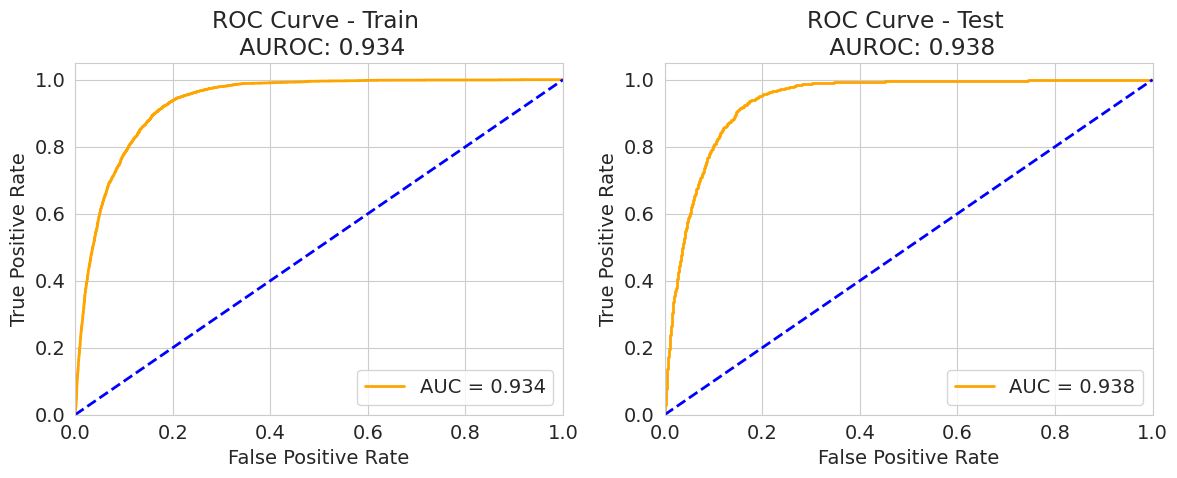

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Ймовірності для train і test
y_pred_proba_train = model.predict_proba(X_train)[:, 1]
y_pred_proba_test = model.predict_proba(X_val)[:, 1]

# ROC для train
fpr_train, tpr_train, _ = roc_curve(train_targets, y_pred_proba_train)
roc_auc_train = auc(fpr_train, tpr_train)

# ROC для test
fpr_test, tpr_test, _ = roc_curve(val_targets, y_pred_proba_test)
roc_auc_test = auc(fpr_test, tpr_test)

# Створюємо два графіки поруч
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC train
axes[0].plot(fpr_train, tpr_train, color='orange', lw=2, label=f'AUC = {roc_auc_train:.3f}')
axes[0].plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curve - Train \n AUROC: {roc_auc_train:.3f}')
axes[0].legend(loc="lower right")

# ROC test
axes[1].plot(fpr_test, tpr_test, color='orange', lw=2, label=f'AUC = {roc_auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve - Test \n AUROC: {roc_auc_test:.3f}')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score

def get_f1_score(inputs, targets, name='', threshold = 0.5):
  y_pred_proba = model.predict_proba(inputs)[:, 1]
  y_pred_05 = (y_pred_proba >= threshold).astype(int)

  f1_score_ = f1_score(targets, y_pred_05)
  print(f"F1 score {name}: {f1_score_:.3f}")

get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')

F1 score Training: 0.505
F1 score Validation: 0.501


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, classification_report, root_mean_squared_error, r2_score

Area under ROC score on Training dataset: 0.80


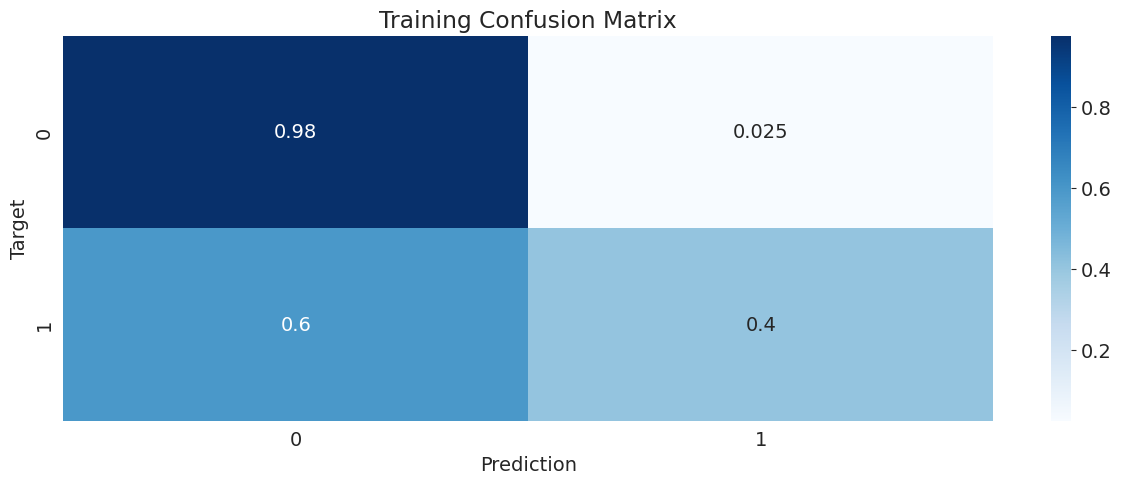

Area under ROC score on Validation dataset: 0.79


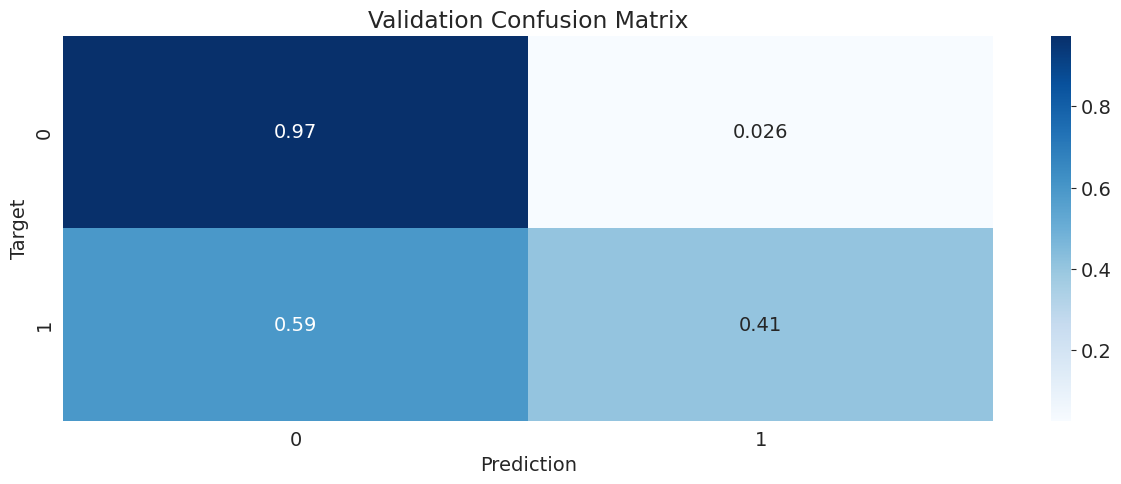

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.66      0.41      0.50       928

    accuracy                           0.91      8236
   macro avg       0.79      0.69      0.73      8236
weighted avg       0.90      0.91      0.90      8236



In [ ]:
# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    roc_auc = roc_auc_score(preds, targets)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure(10, 6)
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Training')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Звіт про класифікацію
print(classification_report(val_targets, model_pipeline.predict(val_inputs)))

Area under ROC score on Training dataset: 0.80


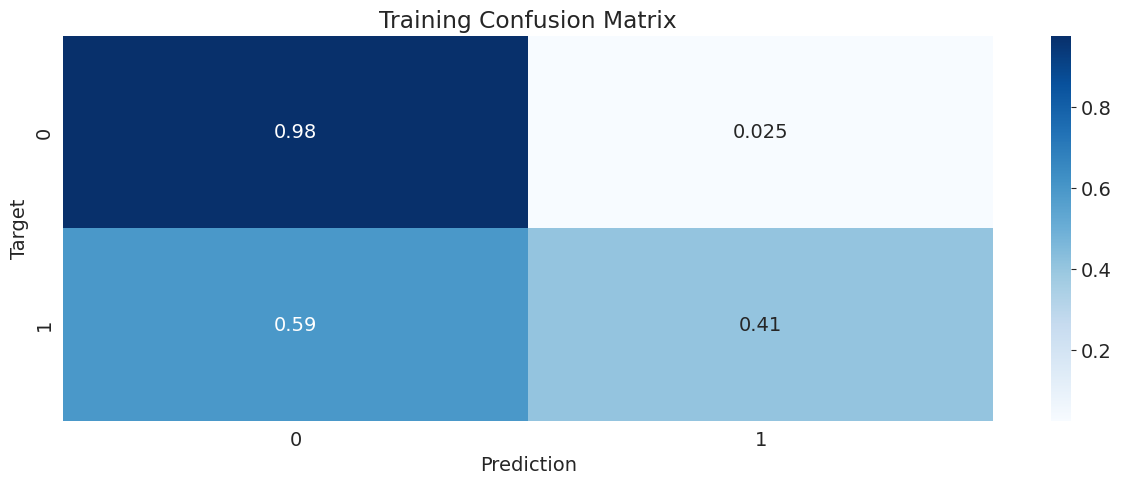

Area under ROC score on Validation dataset: 0.79


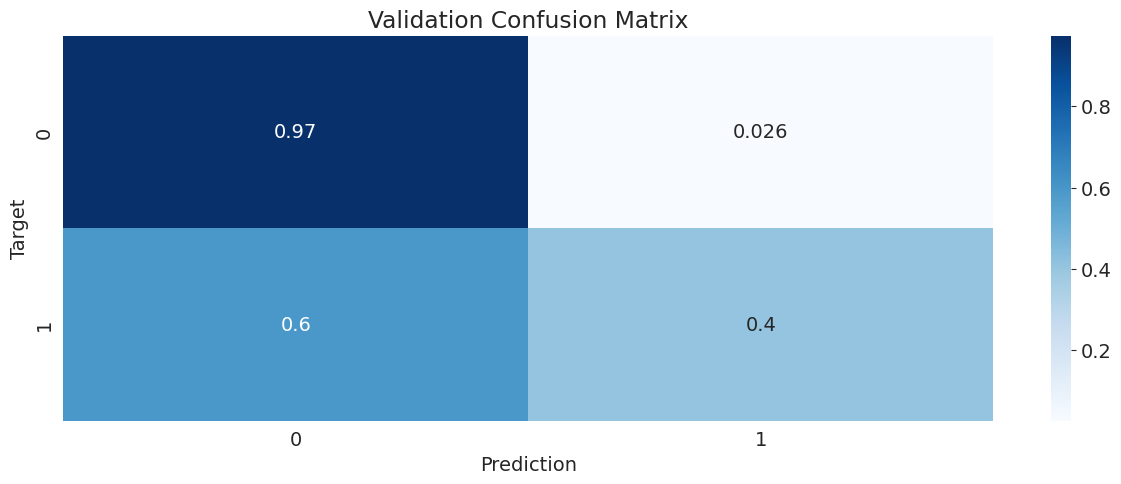

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.66      0.40      0.50       928

    accuracy                           0.91      8236
   macro avg       0.79      0.69      0.73      8236
weighted avg       0.90      0.91      0.90      8236



In [ ]:
import operator
from sklearn.preprocessing import PolynomialFeatures

# Створюємо трансформери для числових і категоріальних колонок колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('polynomial_features', PolynomialFeatures(degree=1))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_pol2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline_pol2.fit(train_inputs, train_targets)

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline_pol2, train_inputs, train_targets, 'Training')
val_preds = predict_and_plot(model_pipeline_pol2, val_inputs, val_targets, 'Validation')

# Звіт про класифікацію
print(classification_report(val_targets, model_pipeline_pol2.predict(val_inputs)))

In [ ]:
train_inputs.describe()

,age,duration,campaign,pdays_change,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
count,32940.000000,32940.000000,32940.000000,32940.000000,32940.000000,32940.000000,32940.000000,32940.000000,32940.000000,32940.000000,...,32940.000000,32940.000000,32940.000000,32940.000000,32940.000000,32940.000000,32940.000000,32940.000000,32940.000000,32940.000000
mean,0.284162,0.061382,0.028399,0.008259,0.024829,0.725028,0.535701,0.430551,0.676503,0.768643,...,0.334517,0.099089,0.017638,0.013995,0.206861,0.207620,0.194930,0.198512,0.863115,0.033212
std,0.129054,0.061324,0.050363,0.050636,0.071225,0.327396,0.225826,0.193685,0.393546,0.273716,...,0.471829,0.298786,0.131634,0.117472,0.405061,0.405609,0.396153,0.398886,0.343731,0.179192
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.185185,0.024291,0.000000,0.000000,0.000000,0.333333,0.340608,0.338912,0.160961,0.512287,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.259259,0.042629,0.018182,0.000000,0.000000,0.937500,0.603274,0.376569,0.957379,0.859735,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.370370,0.075970,0.036364,0.000000,0.000000,1.000000,0.698753,0.602510,0.980957,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## kNN

In [ ]:
from mlxtend.plotting import plot_decision_regions
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# X_train = train_inputs.copy()
# #train_targets = data['y_train']
# X_val = val_inputs.copy()
# #val_targets = data['y_val']

In [ ]:
def auroc_train_and_val(model, X_train, X_val, train_targets, val_targets):

  train_probs = model.predict_proba(X_train)
  val_probs = model.predict_proba(X_val)

  # рахуємо ROC-криві
  fpr_train, tpr_train, _ = roc_curve(train_targets, train_probs[:, 1])
  fpr_val, tpr_val, _ = roc_curve(val_targets, val_probs[:, 1])

  # обчислюємо AUC
  auc_train = roc_auc_score(train_targets, train_probs[:, 1])
  auc_val = roc_auc_score(val_targets, val_probs[:, 1])

  # будуємо графік
  plt.figure(figsize=(8, 6))
  plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.4f})")
  plt.plot(fpr_val, tpr_val, label=f"Validation ROC (AUC = {auc_val:.4f})")
  plt.plot([0, 1], [0, 1], linestyle='--', color='green')

  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.legend()
  plt.show()

In [ ]:
# Функція, щоб передбачати  значення і рахувати метрики
def predict_and_plot(model, inputs, targets, name=''):
    pred_prob = model.predict_proba(inputs)
    predict = model.predict(inputs)
    # roc_auc = roc_auc_score(targets, pred_prob[:, 1])
    # print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")
    confusion_matrix_ = confusion_matrix(targets,predict, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()

    # Звіт про класифікацію
    #print(classification_report(targets, predict))

    report = classification_report(targets, predict, output_dict=True)
    df_report = pd.DataFrame(report).transpose()

    # Printing with 3 decimal places
    print(df_report.round(3))

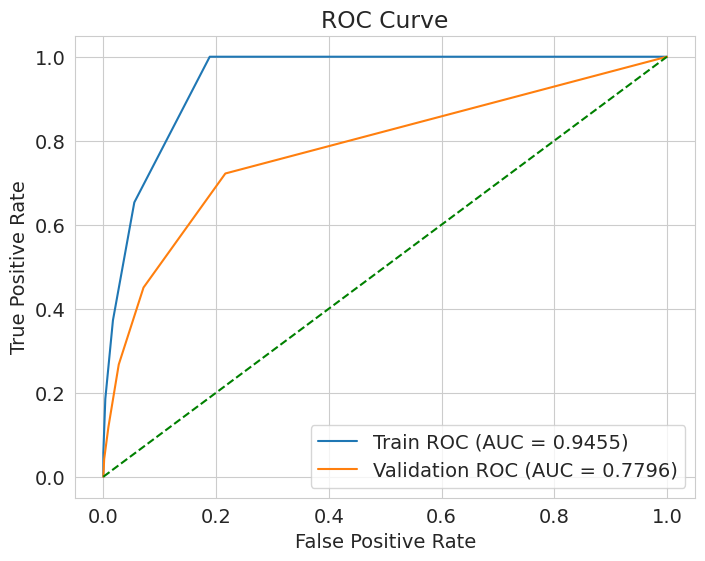

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)
auroc_train_and_val(knn, X_train, X_val, train_targets, val_targets)

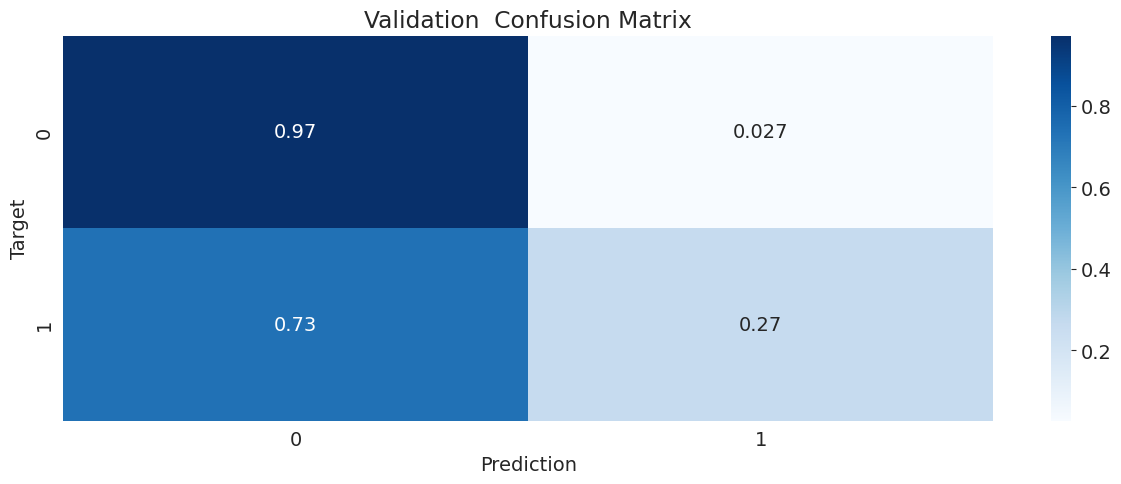

              precision  recall  f1-score   support
0                 0.913   0.973     0.942  7308.000
1                 0.554   0.267     0.360   928.000
accuracy          0.893   0.893     0.893     0.893
macro avg         0.733   0.620     0.651  8236.000
weighted avg      0.872   0.893     0.876  8236.000


In [ ]:
predict_and_plot(knn, X_val, val_targets, name='Validation ')

In [ ]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, train_targets)
print('Найкраще значення параметра', knn_gs.best_params_)

Найкраще значення параметра {'n_neighbors': np.int64(24)}


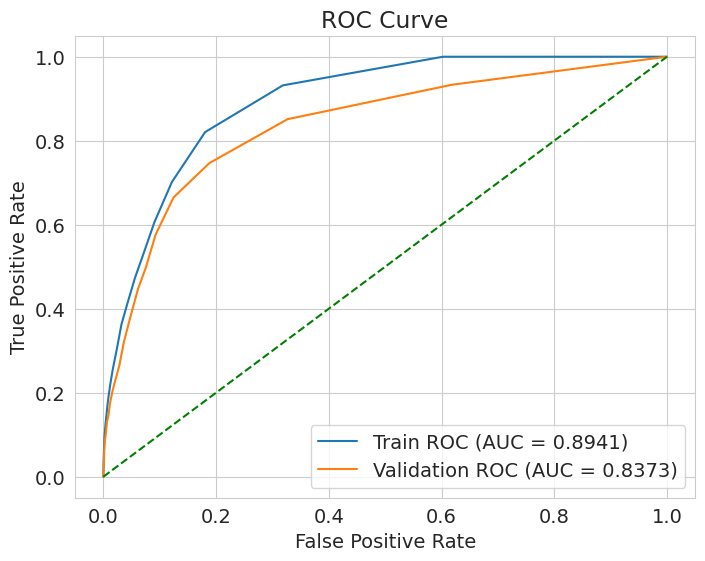

In [ ]:
knn_best = knn_gs.best_estimator_
auroc_train_and_val(knn_best, X_train, X_val, train_targets, val_targets)

## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve

y_train = train_targets
y_val = val_targets

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

train_probs = model.predict_proba(X_train)
print('Для тренувальних даних roc_auc_score = ', roc_auc_score(y_train, train_probs[:, 1]))

val_probs = model.predict_proba(X_val)
print('Для валідаційних даних roc_auc_score = ',roc_auc_score(y_val, val_probs[:, 1]).round(3))

Для тренувальних даних roc_auc_score =  1.0
Для валідаційних даних roc_auc_score =  0.728


In [ ]:
importance_df = model.feature_importances_.round(2)

In [ ]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

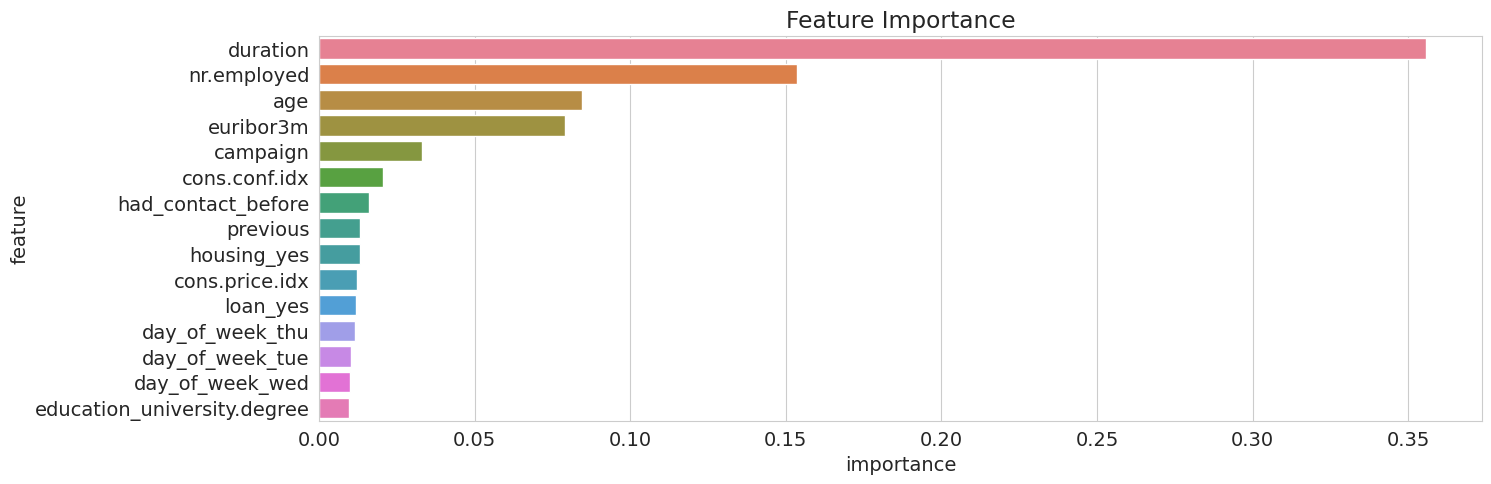

In [ ]:
import seaborn as sns
sns.barplot(
    data=importance_df.head(15),
    x='importance',
    y='feature',
    hue='feature',  # щоб різні кольори були для кожної ознаки
    palette=sns.color_palette("husl", 15),
)
plt.title('Feature Importance')
plt.show()


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

tree = DecisionTreeClassifier(random_state = 42)
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}
random_search = RandomizedSearchCV(
    tree,
    params_dt,
    n_iter = 40,
    cv=3,
    scoring='roc_auc',
    refit=True
    )
tree_search = random_search.fit(X_train, train_targets)
print('Найкращі значення параметрів', tree_search.best_params_)

Найкращі значення параметрів {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_leaf_nodes': np.int64(19), 'max_features': None, 'max_depth': np.int64(10), 'criterion': 'entropy'}


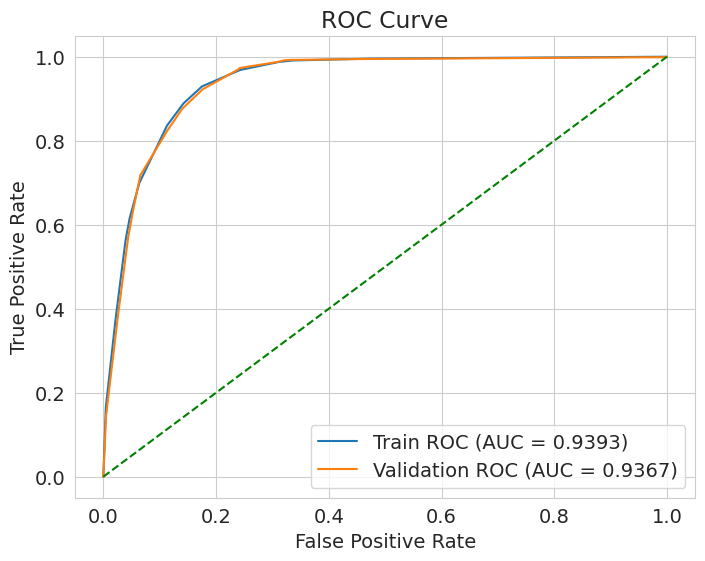

In [ ]:
dt_random_search_best = tree_search.best_estimator_
auroc_train_and_val(dt_random_search_best, X_train, X_val, train_targets, val_targets)

##  Aлгоритми бустингу

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [ ]:
def detect_outliers(df, column, remove=False):
    """
    Виявляє викиди у вказаній колонці датафрейму.

    Параметри:
        df (pd.DataFrame): датафрейм
        column (str): назва колонки
        remove (bool): якщо True — видаляє викиди

    Повертає:
        dict: {'count': кількість викидів, 'rows': індекси рядків з викидами}
        pd.DataFrame: (якщо remove=True) — датафрейм без викидів
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    result = {
        'count': len(outliers),
        'rows': outliers.index.tolist()
    }

    if remove:
        df = df.drop(outliers.index)
        return result, df
    else:
        return result

In [ ]:
# df_boost = df[['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
#        'contact', 'month', 'day_of_week', 'duration', 'campaign',
#        'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
#        'cons.conf.idx', 'euribor3m', 'nr.employed',
#        'pdays_clean', 'y_num']]
df_boost = pd.read_csv('/content/train.csv')
X_test = pd.read_csv('/content/test.csv')

# df_boost['y'] = df_boost['y'].map({'no': 0, 'yes': 1})

train_df, val_df = split_train_val(df_boost, 'y')


In [ ]:
columns_for_checking_outliers = ['duration']
for col in columns_for_checking_outliers:
  print(detect_outliers(train_df, col))
#res, df_clean = detect_outliers(train_df,'duration', remove=True)

{'count': 2349, 'rows': [1233, 41164, 4268, 40513, 30046, 37483, 8817, 17364, 5525, 19121, 2616, 22611, 5505, 18638, 15473, 15810, 31463, 8948, 1114, 11716, 38403, 9732, 16578, 7397, 31754, 19752, 25567, 18745, 14859, 19826, 13700, 18596, 10083, 25915, 29750, 2275, 17934, 13609, 1691, 21459, 9204, 30777, 13989, 41010, 6164, 12217, 6213, 3071, 16835, 590, 4720, 21435, 6394, 8279, 15209, 30408, 29239, 12133, 7083, 39853, 17723, 26488, 16198, 39907, 16254, 34382, 18288, 11575, 32484, 25933, 10299, 4609, 24641, 8315, 14554, 13281, 24012, 8554, 29926, 34383, 26472, 36390, 32134, 20996, 26041, 19736, 17789, 40001, 30139, 9998, 7835, 17639, 31400, 16841, 33444, 19521, 33124, 24316, 27541, 22123, 17830, 11640, 29512, 32882, 39106, 36756, 16922, 8196, 33799, 20381, 36675, 37, 11150, 20187, 29557, 17679, 8294, 3693, 27181, 38526, 35352, 35174, 7478, 18900, 24024, 16161, 34407, 7933, 11556, 5222, 15165, 28939, 9555, 30760, 4982, 30389, 32049, 31932, 15666, 1568, 9156, 36264, 36557, 7009, 28255, 1

In [ ]:
train_df

,age,job,marital,education,default,housing,loan,contact,month,duration,...,pdays_change,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,had_contact_before,y_num
36454,24,technician,single,professional.course,no,no,no,cellular,jun,122,...,0,1,failure,-2.9,92.963,-40.8,1.262,5076.2,0,0
1233,32,blue-collar,married,professional.course,no,no,no,telephone,may,1119,...,0,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0,1
24111,33,self-employed,single,university.degree,no,no,no,telephone,nov,168,...,0,0,nonexistent,-0.1,93.200,-42.0,4.245,5195.8,0,0
15516,38,entrepreneur,married,basic.9y,no,no,yes,telephone,jul,129,...,0,0,nonexistent,1.4,93.918,-42.7,4.957,5228.1,0,0
17916,39,services,married,high.school,no,yes,yes,cellular,jul,197,...,0,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33267,26,services,married,basic.9y,no,no,no,telephone,may,43,...,0,0,nonexistent,-1.8,92.893,-46.2,1.291,5099.1,0,0
22714,35,management,married,university.degree,no,no,yes,cellular,aug,873,...,0,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,0,1
6971,32,management,married,university.degree,no,yes,no,telephone,may,619,...,0,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0,0
18503,34,technician,married,professional.course,unknown,no,no,cellular,jul,61,...,0,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,0,0


In [ ]:
train_df, val_df = split_train_val(df_boost, 'y')
X_train, train_targets = separate_inputs_targets(train_df, train_df.columns[:-1], train_df.columns[-1])
X_val, val_targets = separate_inputs_targets(val_df, val_df.columns[:-1], val_df.columns[-1])

In [ ]:
cat_features = X_train.select_dtypes(include='object').columns
X_train[cat_features] = X_train[cat_features].astype('category')
X_val[cat_features] = X_val[cat_features].astype('category')
X_test[cat_features] = X_test[cat_features].astype('category')

In [ ]:
model_report= pd.DataFrame({'model': [], 'train_auroc': [], 'val_auroc': [], 'auroc_dif': [], 'kaggle_score':[], 'best_param' : [], 'info':[]})
random_state_fix = 1

In [ ]:
def AUROC_report_for_model(model, X_train, X_val, train_targets, val_targets):
  train_proba = model.predict_proba(X_train)[:, 1]
  val_proba = model.predict_proba(X_val)[:, 1]

  train_predict  = model.predict(X_train)
  val_predict = model.predict(X_val)

  train_auroc = round(roc_auc_score(train_targets, train_proba), 5)
  val_auroc = round(roc_auc_score(val_targets, val_proba), 5)

  print('Train AUROC:', train_auroc)
  print('Validation AUROC:', val_auroc)

  # # Обчислюємо матриці і метрики
  # cm_train = confusion_matrix(train_targets, train_predict, normalize='true')
  # cm_test = confusion_matrix(val_targets, val_predict, normalize='true')

  # # Малюємо поруч
  # fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  # ConfusionMatrixDisplay(cm_train).plot(ax=axes[0], colorbar=False)
  # axes[0].set_title(f'Train Confusion Matrix')

  # ConfusionMatrixDisplay(cm_test).plot(ax=axes[1], colorbar=False)
  # axes[1].set_title(f'Validation Confusion Matrix')

  # plt.tight_layout()
  # plt.show()

  # # Виведення звіту класифікації для валідаційної вибірки
  # print("Звіт класифікації на валідаційній вибірці:")
  # print(classification_report(val_targets, val_predict, digits=4))

  return train_auroc, val_auroc

### Xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report,  roc_auc_score

param =     {'max_depth': 3,
          'n_estimators': 30,
    'enable_categorical': True,
                #'device':'cuda'
    }

xgb_clf = XGBClassifier(**param)
xgb_clf.fit(X_train, train_targets)

train_auroc, val_auroc = AUROC_report_for_model(xgb_clf, X_train, X_val, train_targets, val_targets)

# Оновлюємо model_report, додаючи новий рядок
model_report.loc[len(model_report)] = pd.Series({
    'model': 'xgb_clf',
    'train_auroc': train_auroc,
    'val_auroc': val_auroc,
    'auroc_dif': train_auroc - val_auroc,
    'best_param': param
})

Train AUROC: 0.95689
Validation AUROC: 0.95724


#### Oптимальні значення гіперпараметрів XGBoostClassifier

In [ ]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import roc_auc_score, accuracy_score

In [ ]:
def objective(params):
    clf = xgb.XGBClassifier(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        #use_label_encoder=False,
        missing=np.nan,
        #device='cuda',
        early_stopping_rounds=10,
        random_state= random_state_fix,  # <<< Додано для фіксації випадковості моделі
        )

    clf.fit(
        X_train,
        train_targets,
        eval_set=[(X_val, val_targets)],
        verbose=False)
    pred = clf.predict_proba(X_val)[:, 1]
    AUROC = roc_auc_score(val_targets, pred)


    return {'loss': -AUROC, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=50, trials=trials, rstate=np.random.default_rng(random_state_fix) )  # max_evals=50 кількість ітерацій


# Перетворення значень гіперпараметрів у кінцеві типи даних
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    #use_label_encoder=False,
    missing=np.nan,
    #device='cuda',
    random_state=random_state_fix,  # <<< Додано для фіксації випадковості моделі
    )

final_clf.fit(X_train, train_targets)

train_auroc, val_auroc = AUROC_report_for_model(final_clf, X_train, X_val, train_targets, val_targets)

# Оновлюємо model_report, додаючи новий рядок
model_report.loc[len(model_report)] = pd.Series({
    'model': 'final_clf',
    'train_auroc': train_auroc,
    'val_auroc': val_auroc,
    'auroc_dif': train_auroc - val_auroc,
    'best_param':best,
    'info':[f'random state = {random_state_fix}', 'hyperopt']
})

100%|██████████| 50/50 [43:41<00:00, 52.42s/trial, best loss: -0.9679292256663043]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.6874930577157307), 'gamma': np.float64(0.4438674603613809), 'learning_rate': np.float64(0.028200273415830063), 'max_depth': 13, 'min_child_weight': 3, 'n_estimators': 375, 'reg_alpha': np.float64(0.8298461648702138), 'reg_lambda': np.float64(0.7243484763908119), 'subsample': np.float64(0.8409793517019918)}
Train AUROC: 0.98567
Validation AUROC: 0.96793


In [ ]:
#model_report = model_report.drop(index = [0, 1])
model_report

,model,train_auroc,val_auroc,auroc_dif,kaggle_score,best_param,info
2,final_clf,0.98567,0.96793,0.01774,NaN,"{'colsample_bytree': 0.6874930577157307, 'gamm...","[random state = 1, hyperopt]"
3,final_clf,0.98567,0.96793,0.01774,NaN,"{'colsample_bytree': 0.6874930577157307, 'gamm...","[random state = 1, hyperopt]"
4,xgb_clf,0.95689,0.95724,-0.00035,NaN,"{'max_depth': 3, 'n_estimators': 30, 'enable_c...",NaN


### Lightgbm

In [ ]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


In [ ]:
cat_feature_indexes = [X_train.columns.get_loc(col) for col in cat_features]

param = {'max_depth': 3,
        'n_estimators': 50,
        'learning_rate': 0.1,
        'cat_feature' : cat_feature_indexes,  # для автоматичного розпізнавання категорійних ознак
    # 'missing': np.nan,  # явне вказування пропущених значень
    # # 'device': 'cuda'  # використовувати GPU для прискорення обчислень
        'verbose': -1}
lgb_clf = lgb.LGBMClassifier(**param)
lgb_clf.fit(X_train, train_targets, eval_set=[(X_val, val_targets)])

train_auroc, val_auroc = AUROC_report_for_model(lgb_clf, X_train, X_val, train_targets, val_targets)

# Оновлюємо model_report, додаючи новий рядок
model_report.loc[len(model_report)] = pd.Series({
    'model': 'lgb_clf',
    'train_auroc': train_auroc,
    'val_auroc': val_auroc,
    'auroc_dif': train_auroc - val_auroc,
    'best_param': param,
    'info':[f'random state = {random_state_fix}', 'hyperopt']
})

Train AUROC: 0.95307
Validation AUROC: 0.95363


#### Oптимальні значення гіперпараметрів LightGBM

In [ ]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        cat_feature=cat_feature_indexes,  # Індекси категорійних ознак
        n_jobs=-1,                 # Використовуємо всі CPU ядра
        random_state=random_state_fix
    )

    # clf.fit(X_train, train_targets, eval_set=[(X_val, val_targets)], early_stopping_rounds=50, verbose=False, n_jobs=-1)
    clf.fit(
        X_train, train_targets,
        eval_set=[(X_val, val_targets)],
        eval_metric="auc",
        #early_stopping_rounds=50,  # Зупинка, якщо якість не росте
        #verbose=False
    )
    pred_proba = clf.predict_proba(X_val)[:, 1]
    AUROC = roc_auc_score(val_targets, pred_proba)

    return {'loss': -AUROC, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 300, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)  # додано мінімальне зменшення втрат для поділу
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_lgb = lgb.LGBMClassifier(
    **best,
    # n_estimators=best['n_estimators'],
    # learning_rate=best['learning_rate'],
    # max_depth=best['max_depth'],
    # num_leaves=best['num_leaves'],
    # min_child_weight=best['min_child_weight'],
    # subsample=best['subsample'],
    # colsample_bytree=best['colsample_bytree'],
    # reg_alpha=best['reg_alpha'],
    # reg_lambda=best['reg_lambda'],
    # min_split_gain=best['min_split_gain'],
    cat_feature=cat_feature_indexes,
    missing=np.nan
)

final_lgb.fit(X_train, train_targets, eval_set=[(X_val, val_targets)],eval_metric="auc",
    #            callbacks=[ early_stopping(stopping_rounds=50),  # ✅ правильний спосіб
    #     log_evaluation(period=0)              # вимкнути вивід (0 = без логів)
    # ]
    #early_stopping_rounds=50,
    )

train_auroc, val_auroc = AUROC_report_for_model(lgb_clf, X_train, X_val, train_targets, val_targets)

# Оновлюємо model_report, додаючи новий рядок
model_report.loc[len(model_report)] = pd.Series({
    'model': 'final_lgb',
    'train_auroc': train_auroc,
    'val_auroc': val_auroc,
    'auroc_dif': train_auroc - val_auroc,
    'best_param': best,
    'info':[f'random state = {random_state_fix}', 'hyperopt']
})

In [ ]:
X_test_predict = final_clf.predict_proba(X_test)
df_sample = pd.read_csv('/content/sample_submission.csv')
df_sample['y'] = X_test_predict[:, 1]
df_sample.to_csv('/content/submission_final_clf_05_08_25.csv', index=False)